***
*Project:* [Artificial Neuroscience: metrology and engineering for Deep Learning using Linear Algebra](https://www.seresearch.qmul.ac.uk/cmai/people/msandler/#grants)

*Author:* Jingwei Liu, Postdoctoral Research Associate, School of EECS, Queen Mary University of London

[[Centre for Digital Music (C4DM)](https://www.c4dm.eecs.qmul.ac.uk/people/) & [Centre for Fundamentals of AI and Computational Theory](https://www.seresearch.qmul.ac.uk/cfcs/people/jiliu/)]
***

# <span style="background-color:darkorange; color:white; padding:2px 6px">Document 6_1 [Compact] Model Inference</span> 

# Trained Model Inference and Analysis

*Updated:* March 8, 2026


In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import librosa
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Audio
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from typing import Dict, List, Union, Literal, Tuple, Optional, Any
import warnings

from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from scipy.linalg import subspace_angles
import seaborn as sns
from dataclasses import dataclass

torch.cuda.is_available()

True

In [4]:
from utils0_loss import plot_training_curves, plot_training_curves_dual_round, plot_training_curves_run
from utils_Conv_Tas_Net import ConvTasNet
from utils1_weights import extract_2d_weights_from_state_dict, classify_convtasnet_weights
from utils2_svd import compute_svd, compute_effective_rank, compute_stable_rank
from utils4_analysis import visualize_singular_values_subplots

## 1. Plot Training Loss

In [ ]:
task = "Task1_train_free"

Loading TensorBoard scalars...
  Available tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 points  (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 points  (epoch 1 → 100)

Loading best_val_loss from checkpoints...
  Loaded best_val_loss from checkpoints: 100 data points (epoch 1 → 100)

Global best epoch : 100
  Train Loss       : -9.229649543762207
  Val Loss         : -8.476433753967285


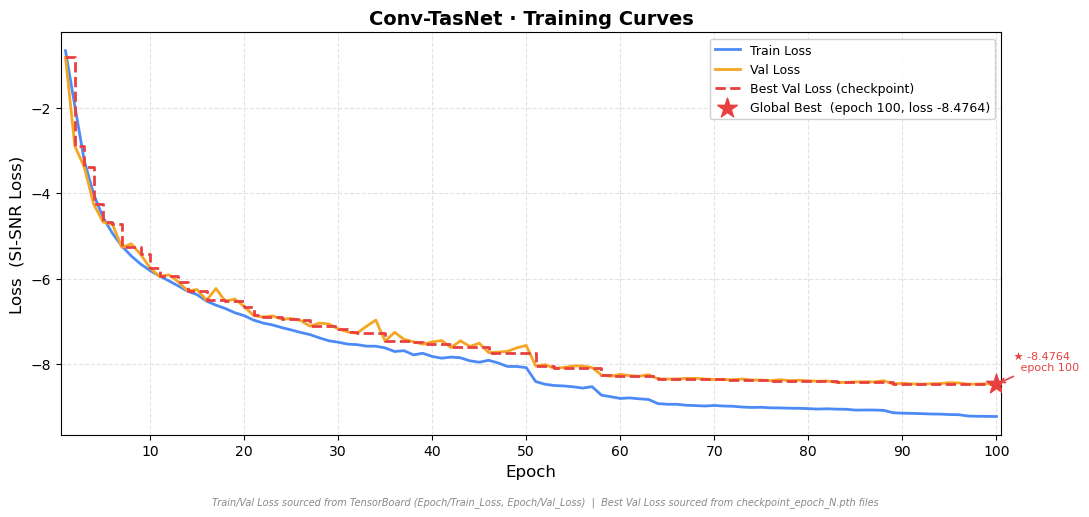

In [105]:
fig = plot_training_curves(
    log_dir        = f'HPC_Trained/{task}/logs',           # your SummaryWriter log_dir
    checkpoint_dir = f'HPC_Trained/{task}/checkpoints',    # your checkpoint_dir
    # save_path      = 'training_curves.png',
    figsize        = (11, 5),
    dpi            = 150,
    smooth_window  = 1,                  # set > 1 (e.g. 5) to smooth noisy curves
)
plt.show()


Run [0] 'Task1'
  log_dir        : HPC_Trained/Task1/logs
  checkpoint_dir : HPC_Trained/Task1/checkpoints
  Loading TensorBoard scalars...
  Available tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 points  (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 points  (epoch 1 → 100)
  Loading best_model.pth...
  best_model.pth → epoch 78,  best_val_loss -14.209594
  => best_epoch=78  |  train_loss_at_best=-16.225563049316406  |  val_loss_at_best=-14.2095947265625

Run [1] 'Task2 · Kernel 30'
  log_dir        : HPC_Trained/Task2_kernel_30/logs
  checkpoint_dir : HPC_Trained/Task2_kernel_30/checkpoints
  Loading TensorBoard scalars...
  Available tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 points  (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 points  (epoch 1 → 100)
  Loading best_model.pth...
  best_model.pth → epoch 66,  best_val_loss -14.058737
  => be

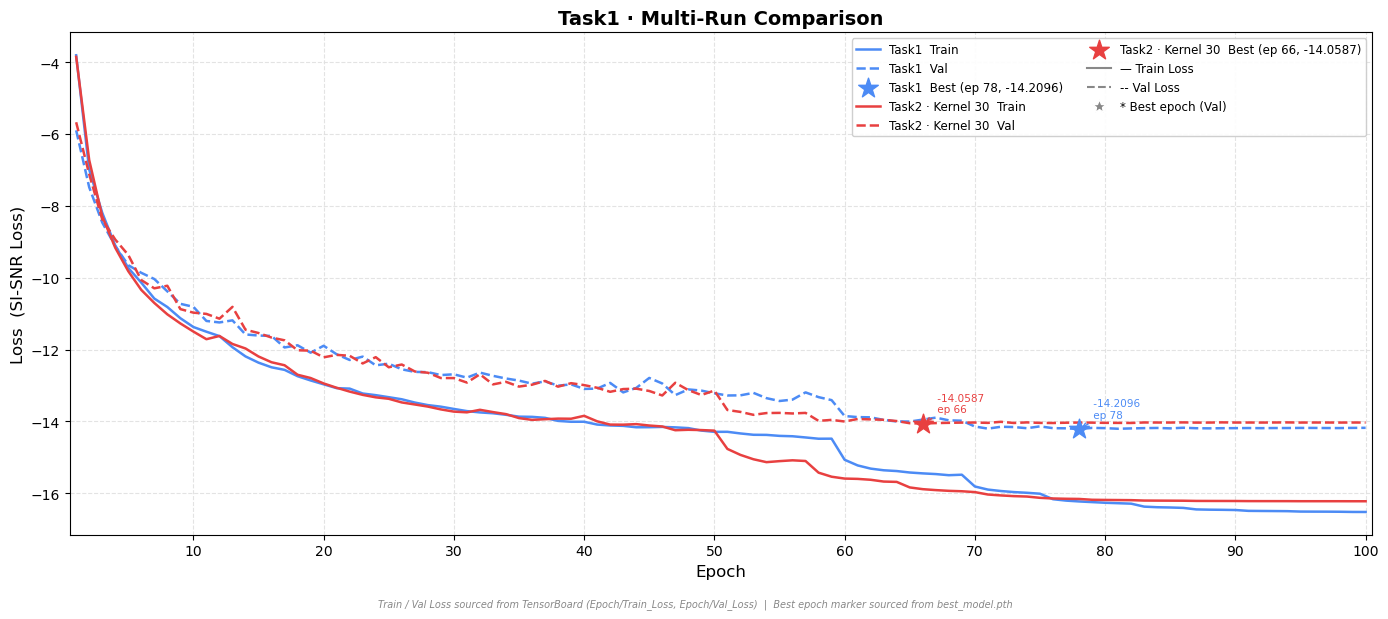

In [306]:
runs = [
    {
        'log_dir':        'HPC_Trained/Task1/logs',
        'checkpoint_dir': 'HPC_Trained/Task1/checkpoints',
        'label':          'Task1',
    },
    {
        'log_dir':        'HPC_Trained/Task2_kernel_30/logs',
        'checkpoint_dir': 'HPC_Trained/Task2_kernel_30/checkpoints',
        'label':          'Task2 · Kernel 30',
    }
]

fig, results = plot_training_curves_run(
    runs          = runs,
    # save_path     = 'multi_run_curves.png',
    figsize       = (14, 6),
    dpi           = 150,
    smooth_window = 1,
    title         = 'Task1 · Multi-Run Comparison',
)

# Inspect per-run best results
for r in results:
    print(f"{r['label']:20s}  "
          f"best_epoch={r['best_epoch']:>4}  "
          f"best_val_loss={r['best_val_loss']:.6f}  "
          f"train@best={r['train_loss_at_best']:.6f}  "
          f"val@best={r['val_loss_at_best']:.6f}")



Run [0] 'Task3 · 3-Mix'
  log_dir        : HPC_Trained/Task3_3mix/logs
  checkpoint_dir : HPC_Trained/Task3_3mix/checkpoints
  Loading TensorBoard scalars...
  Available tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 165 points  (epoch 1 → 165)
  Loaded 'Epoch/Val_Loss': 165 points  (epoch 1 → 165)
  Loading best_model.pth...
  best_model.pth → epoch 112,  best_val_loss -7.805565
  => best_epoch=112  |  train_loss_at_best=-10.477341651916504  |  val_loss_at_best=-7.8055644035339355

Run [1] 'Task3 · 3-Mix · 9-4'
  log_dir        : HPC_Trained/Task3_3mix_9-4/logs
  checkpoint_dir : HPC_Trained/Task3_3mix_9-4/checkpoints
  Loading TensorBoard scalars...
  Available tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 points  (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 points  (epoch 1 → 100)
  Loading best_model.pth...
  best_model.pth → epoch 71,  best_val_lo

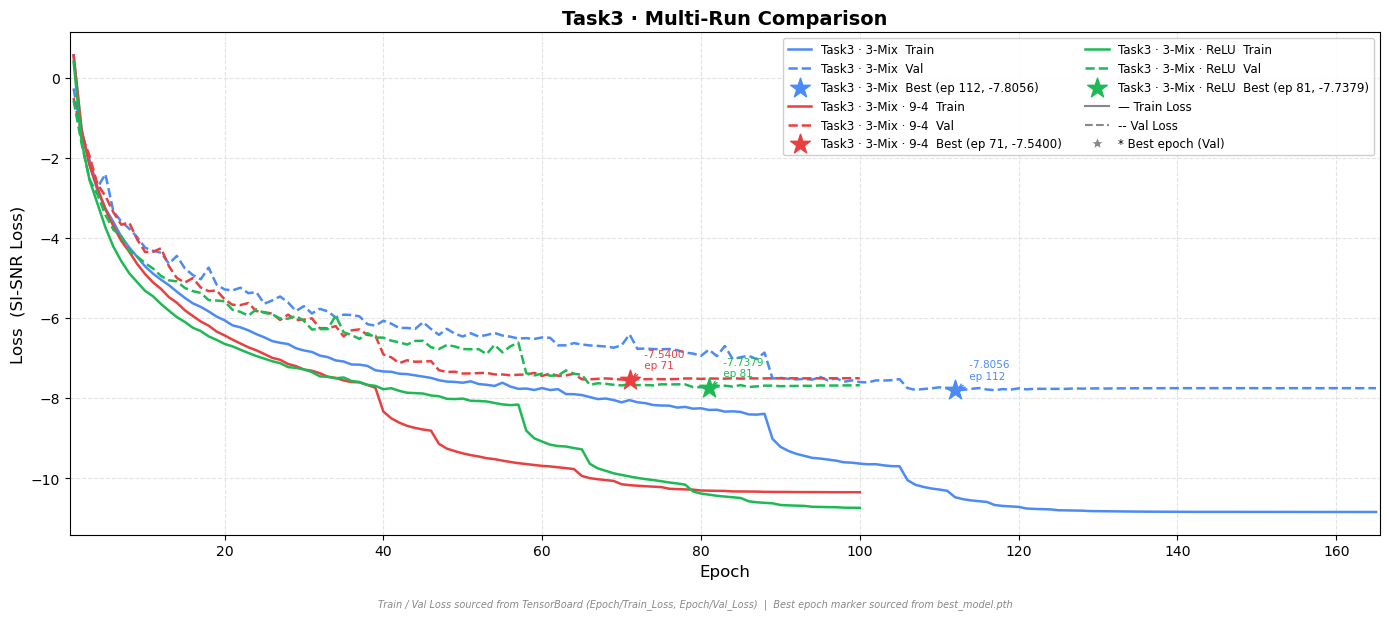

In [6]:
runs = [
    {
        'log_dir':        'HPC_Trained/Task3_3mix/logs',
        'checkpoint_dir': 'HPC_Trained/Task3_3mix/checkpoints',
        'label':          'Task3 · 3-Mix',
    },
    {
        'log_dir':        'HPC_Trained/Task3_3mix_9-4/logs',
        'checkpoint_dir': 'HPC_Trained/Task3_3mix_9-4/checkpoints',
        'label':          'Task3 · 3-Mix · 9-4',
    },
    # {
    #     'log_dir':        'HPC_Trained/Task3_3mix_9-4-256/logs',
    #     'checkpoint_dir': 'HPC_Trained/Task3_3mix_9-4-256/checkpoints',
    #     'label':          'Task3 · 3-Mix · 9-4-256',
    # },
    {
        'log_dir':        'HPC_Trained/Task3_3mix_relu/logs',
        'checkpoint_dir': 'HPC_Trained/Task3_3mix_relu/checkpoints',
        'label':          'Task3 · 3-Mix · ReLU',
    },
]

fig, results = plot_training_curves_run(
    runs          = runs,
    # save_path     = 'multi_run_curves.png',
    figsize       = (14, 6),
    dpi           = 150,
    smooth_window = 1,
    title         = 'Task3 · Multi-Run Comparison',
)

# Inspect per-run best results
for r in results:
    print(f"{r['label']:20s}  "
          f"best_epoch={r['best_epoch']:>4}  "
          f"best_val_loss={r['best_val_loss']:.6f}  "
          f"train@best={r['train_loss_at_best']:.6f}  "
          f"val@best={r['val_loss_at_best']:.6f}")



Run [0] 'Task4 · Music'
  log_dir        : HPC_Trained/Task4_mus/logs
  checkpoint_dir : HPC_Trained/Task4_mus/checkpoints
  Loading TensorBoard scalars...
  Available tags: ['Train/Loss_step', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/SI_SDR_Train_dB', 'Epoch/SI_SDR_Val_dB', 'Epoch/LR']
  Loaded 'Epoch/Train_Loss': 100 points  (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 points  (epoch 1 → 100)
  Loading best_model.pth...
  best_model.pth → epoch 70,  best_val_loss -3.300577
  => best_epoch=70  |  train_loss_at_best=-5.109015941619873  |  val_loss_at_best=-3.300577402114868

Run [1] 'Task4 · Music · 256'
  log_dir        : HPC_Trained/Task4_mus_256/logs
  checkpoint_dir : HPC_Trained/Task4_mus_256/checkpoints
  Loading TensorBoard scalars...
  Available tags: ['Train/Loss_step', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/SI_SDR_Train_dB', 'Epoch/SI_SDR_Val_dB', 'Epoch/LR']
  Loaded 'Epoch/Train_Loss': 100 points  (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 points  (epoch 1 

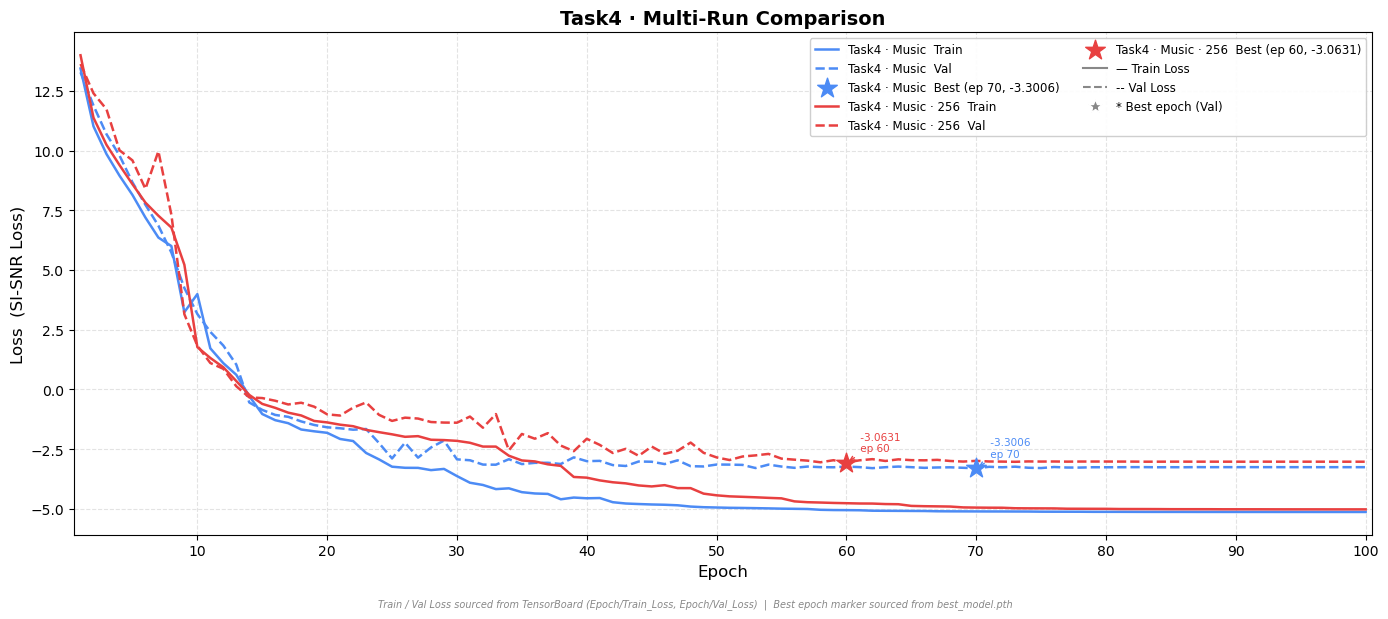

In [5]:
runs = [
    {
        'log_dir':        'HPC_Trained/Task4_mus/logs',
        'checkpoint_dir': 'HPC_Trained/Task4_mus/checkpoints',
        'label':          'Task4 · Music',
    },
    {
        'log_dir':        'HPC_Trained/Task4_mus_256/logs',
        'checkpoint_dir': 'HPC_Trained/Task4_mus_256/checkpoints',
        'label':          'Task4 · Music · 256',
    }
]

fig, results = plot_training_curves_run(
    runs          = runs,
    # save_path     = 'multi_run_curves.png',
    figsize       = (14, 6),
    dpi           = 150,
    smooth_window = 1,
    title         = 'Task4 · Multi-Run Comparison',
)

# Inspect per-run best results
for r in results:
    print(f"{r['label']:20s}  "
          f"best_epoch={r['best_epoch']:>4}  "
          f"best_val_loss={r['best_val_loss']:.6f}  "
          f"train@best={r['train_loss_at_best']:.6f}  "
          f"val@best={r['val_loss_at_best']:.6f}")


### Tensor Board

In [10]:
# %load_ext tensorboard
# %tensorboard --logdir HPC_Trained/Task1/logs --port 7007

In [ ]:
# !netstat -ano | findstr :7007

In [ ]:
# !taskkill /PID 0 /F

## 2. Inference

In [5]:
config = {
    # Model parameters
    'num_sources': 2,
    'encoder_dim': 512,
    'feature_dim': 128,
    'sample_rate': 8000,
    'window_ms': 2,
    'num_layers': 8,
    'num_stacks': 3,
    'kernel_size': 3,
    'causal': False,
    'use_skip': True,
    
    # Training parameters
    'batch_size': 6,
    'num_epochs': 100,
    'learning_rate': 1e-3,
    'weight_decay': 1e-5,
    
    # System parameters
    'device': 'cuda',
    'num_workers': 4,
    'checkpoint_dir': './checkpoints',
    'log_dir': './logs',
}

In [6]:
model = ConvTasNet(
    num_sources=config['num_sources'],
    encoder_dim=config['encoder_dim'],
    feature_dim=config['feature_dim'],
    sample_rate=config['sample_rate'],
    window_ms=config['window_ms'],
    num_layers=config['num_layers'],
    num_stacks=config['num_stacks'],
    kernel_size=config['kernel_size'],
    causal=config['causal'],
    use_skip=config['use_skip']
)

In [65]:
checkpoint = torch.load(f'HPC_Trained/{task}/checkpoints/best_model.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [27]:
mixed_signal, _ = librosa.load('D:\Datasets\Source_Separation_Dataset\Data\LibriSpeech\Libri2Mix\\test-clean\mix_clean\\61_4992_264.wav', sr=config['sample_rate']) # evaluation
mixed_signal.shape

(71720,)

In [28]:
Audio(mixed_signal, rate=config['sample_rate'])

In [29]:
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    separated_signal = model(torch.FloatTensor(mixed_signal).unsqueeze(0))
separated_signal.shape

torch.Size([1, 2, 71720])

In [30]:
Audio(separated_signal[:,1,:].squeeze(), rate=config['sample_rate'])

## 3. Weight Singular Value Analysis

In [116]:
task = "Task1"

In [117]:
checkpoint = torch.load(f'HPC_Trained/{task}/checkpoints/best_model.pth', map_location='cpu')
state_dict = checkpoint['model_state_dict']
# model.load_state_dict(state_dict)

In [118]:
# state_dict = model.state_dict()

In [119]:
weights_2d = extract_2d_weights_from_state_dict(state_dict)
_, linear_weights = classify_convtasnet_weights(weights_2d)

In [120]:
len(linear_weights)

74

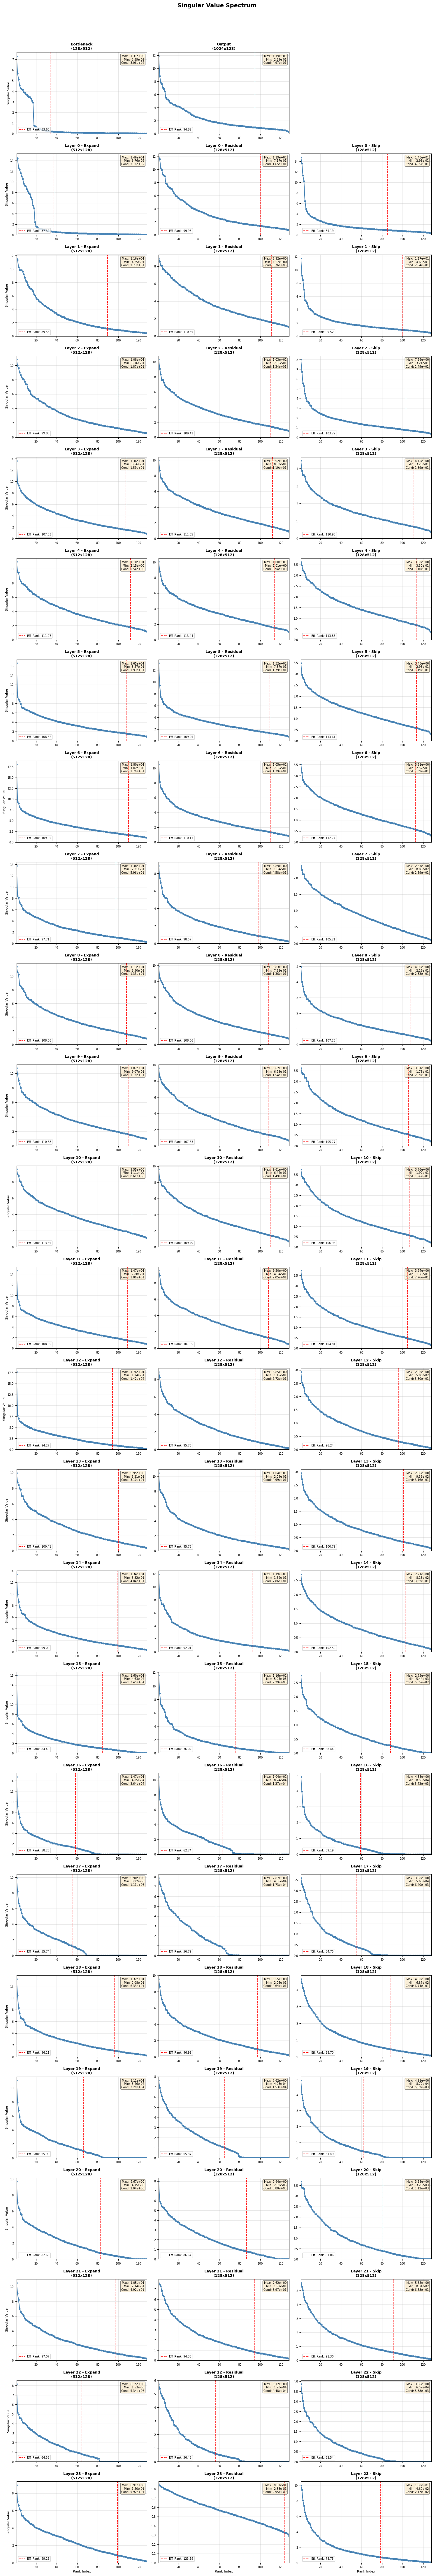

In [129]:
visualize_singular_values_subplots(linear_weights, log_scale=False, figsize_per_subplot=(5, 3.5))

In [122]:
# def visualize_singular_values_subplots(linear_weights, log_scale=False, max_cols=4):
#     """
#     Create separate subplots for each weight matrix.
    
#     Args:
#         linear_weights: Dict of linear weight matrices
#         log_scale: Use log scale for y-axis
#         max_cols: Maximum number of columns in subplot grid
#     """
    
#     n_weights = len(linear_weights)
#     n_cols = min(max_cols, n_weights)
#     n_rows = (n_weights + n_cols - 1) // n_cols
    
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    
#     # Handle single subplot case
#     if n_weights == 1:
#         axes = np.array([axes])
#     axes = axes.flatten()
    
#     # Plot each weight's singular values
#     for idx, (name, weight) in enumerate(linear_weights.items()):
#         ax = axes[idx]
        
#         # Compute SVD
#         svd_result = compute_svd(weight)
#         singular_values = svd_result['S'].cpu().numpy()
#         effective_rank = compute_effective_rank(svd_result['S']).cpu().numpy()
        
#         # Plot
#         indices = np.arange(1, len(singular_values) + 1)
#         ax.plot(indices, singular_values, 'o-', color='steelblue', 
#                 linewidth=2, markersize=4)
#         ax.axvline(effective_rank, color='red', linestyle='--', label=f'Effective Rank: {effective_rank:.2f}')
#         ax.legend()
        
#         # Formatting
#         ax.set_xlabel('Index', fontsize=11)
#         ax.set_ylabel('Singular Value', fontsize=11)
#         ax.set_title(f'{name}\n{weight.shape}', fontsize=10, fontweight='bold')
#         ax.grid(True, alpha=0.3)
        
#         if log_scale:
#             ax.set_yscale('log')
        
#         # Add statistics text
#         max_sv = singular_values[0]
#         min_sv = singular_values[-1]
#         condition_number = max_sv / min_sv if min_sv > 0 else float('inf')
        
#         textstr = f'Max: {max_sv:.2e}\nMin: {min_sv:.2e}\nCond: {condition_number:.2e}'
#         ax.text(0.98, 0.97, textstr, transform=ax.transAxes,
#                 verticalalignment='top', horizontalalignment='right',
#                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
#                 fontsize=8)
    
#     # Hide unused subplots
#     for idx in range(n_weights, len(axes)):
#         axes[idx].set_visible(False)
    
#     plt.tight_layout()
#     plt.show()

# visualize_singular_values_subplots(linear_weights, log_scale=False, max_cols=4)

## 4. SVD Analysis

In [123]:
@dataclass
class FactoredWeight:
    """
    Stores the rank-k SVD factorization of one weight matrix.

    A @ B  reconstructs the best rank-k approximation of the original W.

    Attributes:
        A          : Left  factor  U_k @ diag(sigma_k^0.5)   shape [n, k]
        B          : Right factor  diag(sigma_k^0.5) @ V_k^T shape [k, m]
        rank_k     : Effective rank (rounded integer)
        orig_shape : Original weight shape (n, m)
        compression: Parameter compression ratio  (n*m) / (k*(n+m))
    """
    U_k:           torch.Tensor
    S_k:           torch.Tensor
    Vt_k:          torch.Tensor


def factorize_linear_weights(
    linear_weights: Dict[str, torch.Tensor],
    min_rank:       int  = 1,
    max_rank_frac:  float = 1.0,    # cap rank at this fraction of min(n,m)
) -> Dict[str, FactoredWeight]:
    """
    For each weight W in linear_weights:
      1. Compute full SVD.
      2. Round effective rank to nearest integer k  (clamped to [min_rank, max_rank]).
      3. Return a dict of FactoredWeight objects.

    Args:
        linear_weights: {name: Tensor (n, m)} from a single state_dict.
        min_rank:       Hard floor on k (avoids degenerate rank-1 tensors).
        max_rank_frac:  Soft ceiling — k <= max_rank_frac * min(n, m).
                        Set to 1.0 to allow full rank (no-op for full-rank matrices).

    Returns:
        {name: FactoredWeight}
    """
    factored: Dict[str, FactoredWeight] = {}
    Orig_params_dim = 0
    Fact_params_dim = 0
    for name, weight in linear_weights.items():
        W  = weight.float()                    # ensure float32 for SVD stability
        n, m = W.shape

        # ── SVD ────────────────────────────────────────────────────────── #
        svd_result = compute_svd(W)            # your existing function
        U  = svd_result['U']                   # [n, r]
        S  = svd_result['S']                   # [r]
        Vt = svd_result['Vt']                  # [r, m]

        # ── Effective rank → integer k ──────────────────────────────────── #
        eff_rank = compute_effective_rank(S)
        k = int(round(eff_rank.item()))
        # k = min(n, m)
        # k = int(round(k/2)) # 3/4, 5/4, 3/2, 2/1, etc. to adjust aggressiveness of truncation

        # stable_rank = compute_stable_rank(S)
        # k = int(round(stable_rank.item()))

        k = max(min_rank, k)
        k = min(k, int(max_rank_frac * min(n, m)))
        k = min(k, S.shape[0])                 # can't exceed stored rank

        # ── Truncate ────────────────────────────────────────────────────── #
        U_k  = U[:, :k]                        # [n, k]
        S_k  = S[:k]                           # [k]
        Vt_k = Vt[:k, :]                       # [k, m]

        # # ── Symmetric sqrt-sigma scaling ────────────────────────────────── #
        # # A @ B = (U_k Σ_k^0.5) (Σ_k^0.5 Vt_k) = U_k Σ_k Vt_k = W_k
        # sqrt_S_k = torch.sqrt(S_k)             # [k]
        # A = U_k  * sqrt_S_k.unsqueeze(0)       # [n, k]  broadcast over rows
        # B = Vt_k * sqrt_S_k.unsqueeze(1)       # [k, m]  broadcast over cols

        # ── Compression ratio ────────────────────────────────────────────── #
        orig_params = n * m
        fact_params = k * (n + m)
        compression = orig_params / fact_params

        factored[name] = FactoredWeight(
            U_k         = U_k.to(weight.dtype),
            S_k         = S_k.to(weight.dtype),
            Vt_k        = Vt_k.to(weight.dtype)
        )

        print(
            f'{name:<55}  '
            f'shape ({n:4d},{m:4d})  '
            f'k={k:4d}  '
            f'compression={compression:.2f}x'
        )

        Orig_params_dim += orig_params
        Fact_params_dim += fact_params

    return factored, Orig_params_dim, Fact_params_dim

In [124]:
def build_factored_state_dict(
    original_state_dict: Dict[str, torch.Tensor],
    factored_weights:    Dict[str, FactoredWeight],
    factor_type:         str = 'svd'
) -> Dict[str, torch.Tensor]:
    """
    Construct a new state_dict suitable for a factored Conv-TasNet variant.

    For each factored weight 'encoder.layers.0.linear.weight':
      - Remove the original key
      - Insert  'encoder.layers.0.linear.weight_U'  (shape [n, k])
                'encoder.layers.0.linear.weight_S'  (shape [k])
                'encoder.layers.0.linear.weight_Vt'  (shape [k, m])

    All non-linear keys (biases, norms, etc.) are carried over unchanged.

    Returns:
        New state_dict with A/B pairs substituted for every factored weight.
    """
    new_sd = {}

    for key, tensor in original_state_dict.items():
        if key in factored_weights:
            fw = factored_weights[key]
            module_path = key.rsplit('.', 1)[0]
            if factor_type == 'svd':
                new_sd[f'{module_path}.A'] = fw.U_k * fw.S_k.unsqueeze(0)   # [n, k]
                new_sd[f'{module_path}.B'] = fw.Vt_k    # [k, m]
            elif factor_type == 'sqrt_svd':
                sqrt_S_k = torch.sqrt(fw.S_k)
                new_sd[f'{module_path}.A'] = fw.U_k  * sqrt_S_k.unsqueeze(0)  # [n, k]
                new_sd[f'{module_path}.B'] = sqrt_S_k.unsqueeze(1) * fw.Vt_k  # [k, m]
        else:
            new_sd[key] = tensor.clone()   # bias, LayerNorm, etc. unchanged

    return new_sd

In [125]:
# 1. Load checkpoint
checkpoint = torch.load(f'HPC_Trained/{task}/checkpoints/best_model.pth', map_location='cpu')
state_dict = checkpoint['model_state_dict']
weights_2d = extract_2d_weights_from_state_dict(state_dict)
_, linear_weights = classify_convtasnet_weights(weights_2d)

In [126]:
# 2. Factorize
factored, num_orig_params, num_fact_params = factorize_linear_weights(linear_weights)

separator.bottleneck.weight                              shape ( 128, 512)  k=  34  compression=3.01x
separator.conv_layers.0.conv_expand.weight               shape ( 512, 128)  k=  37  compression=2.77x
separator.conv_layers.0.conv_residual.weight             shape ( 128, 512)  k= 100  compression=1.02x
separator.conv_layers.0.conv_skip.weight                 shape ( 128, 512)  k=  85  compression=1.20x
separator.conv_layers.1.conv_expand.weight               shape ( 512, 128)  k=  90  compression=1.14x
separator.conv_layers.1.conv_residual.weight             shape ( 128, 512)  k= 111  compression=0.92x
separator.conv_layers.1.conv_skip.weight                 shape ( 128, 512)  k= 100  compression=1.02x
separator.conv_layers.2.conv_expand.weight               shape ( 512, 128)  k= 100  compression=1.02x
separator.conv_layers.2.conv_residual.weight             shape ( 128, 512)  k= 109  compression=0.94x
separator.conv_layers.2.conv_skip.weight                 shape ( 128, 512)  k= 103

In [127]:
num_reduced = num_orig_params - num_fact_params
print(f'Original number of parameters in linear layers: {num_orig_params:,}')
print(f'Number of parameters after factorization: {num_fact_params:,}')
print(f'Parameters reduced: {num_reduced:,}')
print(f"Compression ratio: {num_orig_params / (num_fact_params):.2f}x")

Original number of parameters in linear layers: 4,915,200
Number of parameters after factorization: 4,441,600
Parameters reduced: 473,600
Compression ratio: 1.11x


In [128]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f'Param Reduced Ratio: {num_reduced / total_params *100:.2f}%')

Total parameters: 5,050,545
Param Reduced Ratio: 9.38%


| Parameters | Total # | Linear # | Factored # | Compression Ratio (Total) | Receptive Field (seconds) | Best Validation Loss (Original) | Factored Validation Loss (before fine-tuning) | Best Validation Loss (fine-tuned free) | Best Validation Loss (fine-tuned rebalance) |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 2mix (Original) | 5,050,545 | 4,915,200 | 4,441,600 | 1.10x | 1.532s | -14.2096 (ep 78) | -14.0033 | -14.2366 (ep +18) | -14.2339 (ep +7) |
| 2mix (Kernel 6) | 4,441,600 | 2,208,384 | 3,314,432 | 5,369,856 | 5,716,736|
| 2mix (512-256) | 473,600 | 2,706,816 | 1,600,768 | -454,656 |-801,536 |
| 2mix (256-128) | 9.64% | 55.07% | 32.57% | -9.25% |-16.31% |
| 3mix (Original) | 5,050,545 | 4,980,736 | 4,234,752 | 1.17x | 1.532s | -8.0854 (ep 68) | -7.7822 | -8.1018 (ep +19) | -8.1243 (ep +19) |
| 3mix (9-4) | -14.0033 | -10.7458 | -13.1871 | -14.1998 |-14.2095 |

| Effective Rank Ratio | 0.1 | 0.2 | 0.3 | 0.4 | 0.5 | 0.6 | 0.7 | 0.8 | 0.9 | 1 (eff) | 1.1 | 1.2 | 1.3 | 1.4 | 1.5 | full |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 2mix (Original)/ -14.2096 | -9.8351 (0.7177) [8.71x, ep+56] | -12.2977 (1.3163) [4.93x, ep+51] | -13.3362 (-2.1353) [3.44x, ep+52] | -13.7470 (-8.2283) [2.64x, ep+38] | -13.9976 (-10.7592) [2.14x, ep+38] | -14.0856 (-12.1045) [1.80x, ep+15] | -14.1430 (-12.9411) [1.56x, ep+25] | -14.2181 (-13.4710) [1.37x, ep+19] | -14.2162 (-13.8072) [1.22x, ep+11] | -14.2339 (-14.0033) [1.10x, ep+7] | -14.2247 (-14.1314) [1.01x, ep+13] | -14.2241 (-14.1845) [0.94x, ep+9] | -14.2350 (-14.2017) [0.90x, ep+19] | -14.2390 (-14.2096) [0.88x, ep+15] | -14.2742 (-14.2101) [0.86x, ep+13]| -14.2507 (-14.2097) [0.81x, ep+16] |
| 2mix (Kernel 6) | |  |  |  |  | |  |  |  |  |  |  |  |  |  |
| 2mix (512-256) |   |  |  |  |  | |  |  |  |  |  |  |  |  |  |
| 2mix (256-128) |  |  |  |  |  | |  |  |  |  |  |  |  |  |  |
| 3mix (Original)/ -8.0854 |  | (3.8070) [5.19x] |  |  | -7.6804 (-3.2456) [2.31x, ep+27] | |  | -8.0776 (-7.0144) [1.45x, ep+28] |  | -8.1243 (-7.7822) [1.17x, ep+19] |  | -8.1341 (-8.0526) [0.99x, ep+23] |  |  | -8.1367 (-8.0845) [0.88x, ep+25] | |
| 3mix (9-4) |  |  |  |  | | |  |  |  |  |  |  |  |  |  |

| Effective Rank Ratio | Validation Loss After Fine-Tuning | Factored Validation Loss | Parameter Compression Ratio | Additional Fine-Tuned Epochs |
|---|---:|---:|---:|---:|
| 0.1 | -9.8351 | 0.7177 | 8.71x | 56 |
| 0.2 | -12.2977 | 1.3163 | 4.93x | 51 |
| 0.3 | -13.3362 | -2.1353 | 3.44x | 52 |
| 0.4 | -13.7470 | -8.2283 | 2.64x | 38 |
| 0.5 | -13.9976 | -10.7592 | 2.14x | 38 |
| 0.6 | -14.0856 | -12.1045 | 1.80x | 15 |
| 0.7 | -14.1430 | -12.9411 | 1.56x | 25 |
| 0.8 | -14.2181 | -13.4710 | 1.37x | 19 |
| 0.9 | -14.2162 | -13.8072 | 1.22x | 11 |
| 1 (eff) | -14.2339 | -14.0033 | 1.10x | 7 |
| 1.1 | -14.2247 | -14.1314 | 1.01x | 13 |
| 1.2 | -14.2241 | -14.1845 | 0.94x | 9 |
| 1.3 | -14.2350 | -14.2017 | 0.90x | 19 |
| 1.4 | -14.2390 | -14.2096 | 0.88x | 15 |
| 1.5 | -14.2742 | -14.2101 | 0.86x | 13 |
| full | -14.2507 | -14.2097 | 0.81x | 16 |

| Parameters | Compression Ratio (Linear) | Param Reduced Ratio (Total) | Validation Loss (Original) | Factored Validation Loss (before training) | Best Validation Loss (after training)|
|---|---:|---:|---:|---:|---:|
| Epoch 10 (Effective Rank) | 1.24x | 19.13% |-10.8078 | -10.7734 | -13.9449 (ep +81) |
| Epoch 5 (Effective Rank) | 1.35x | 25.32% |-9.6479 | -9.6290 | -13.7195 (ep +88) |
| Epoch 1 (Effective Rank) | 1.41x | 28.10% |-5.8962 | -5.8926 | -13.5912 (ep +95) |
| Random Init (Best Eff. Rank) | 1.11x | 9.38% | / | / | -8.4764 (ep +100) |
| Epoch 10 (Half Effective Rank) | 2.49x | 58.16% |-10.8078 | -10.1671 | -13.6216 (ep +83) |
| Epoch 5 (Half Effective Rank) | 2.70x | 61.32% |-9.6479 | -9.3568 | -13.3547 (ep +81) |
| Epoch 1 (Half Effective Rank) | 2.81x | 62.71% |-5.8962 | -5.8578 | -13.3419 (ep +89) |
| Epoch 10 (Quarter Effective Rank) | 4.96x | 77.72% | -10.8078 | -7.7510 | -12.9179 (ep +69) |
| Epoch 5 (Quarter Effective Rank) | 5.41x | 79.34% | -9.6479 | -7.8804 | -12.2960 (ep +85) |
| Epoch 1 (Quarter Effective Rank) | 5.60x | 79.95% | -5.8962 | -5.7438 | -12.5440 (ep +85) |

In [72]:
# 3. Build the new state_dict
factored_sd = build_factored_state_dict(state_dict, factored, factor_type='sqrt_svd')

In [73]:
# 4. Inspect
for k, v in factored_sd.items():
    print(f'{k:<60} {tuple(v.shape)}')

encoder.weight                                               (512, 1, 16)
separator.input_norm.weight                                  (512,)
separator.input_norm.bias                                    (512,)
separator.bottleneck.A                                       (128, 21)
separator.bottleneck.B                                       (21, 512)
separator.bottleneck.bias                                    (128,)
separator.conv_layers.0.conv_expand.A                        (512, 24)
separator.conv_layers.0.conv_expand.B                        (24, 128)
separator.conv_layers.0.conv_expand.bias                     (512,)
separator.conv_layers.0.conv_depthwise.weight                (512, 1, 3)
separator.conv_layers.0.conv_depthwise.bias                  (512,)
separator.conv_layers.0.conv_residual.A                      (128, 20)
separator.conv_layers.0.conv_residual.B                      (20, 512)
separator.conv_layers.0.conv_residual.bias                   (128,)
separator.conv_laye

In [74]:
# 5. Save for later training
torch.save(factored_sd, f'HPC_Trained/{task}/factored_state_dict_epoch_1_quarter.pth')

- train_loss: -16.2256
- train_loss_truncated: -15.92036

- val_loss: -14.2096
- val_loss_truncated: -14.0033

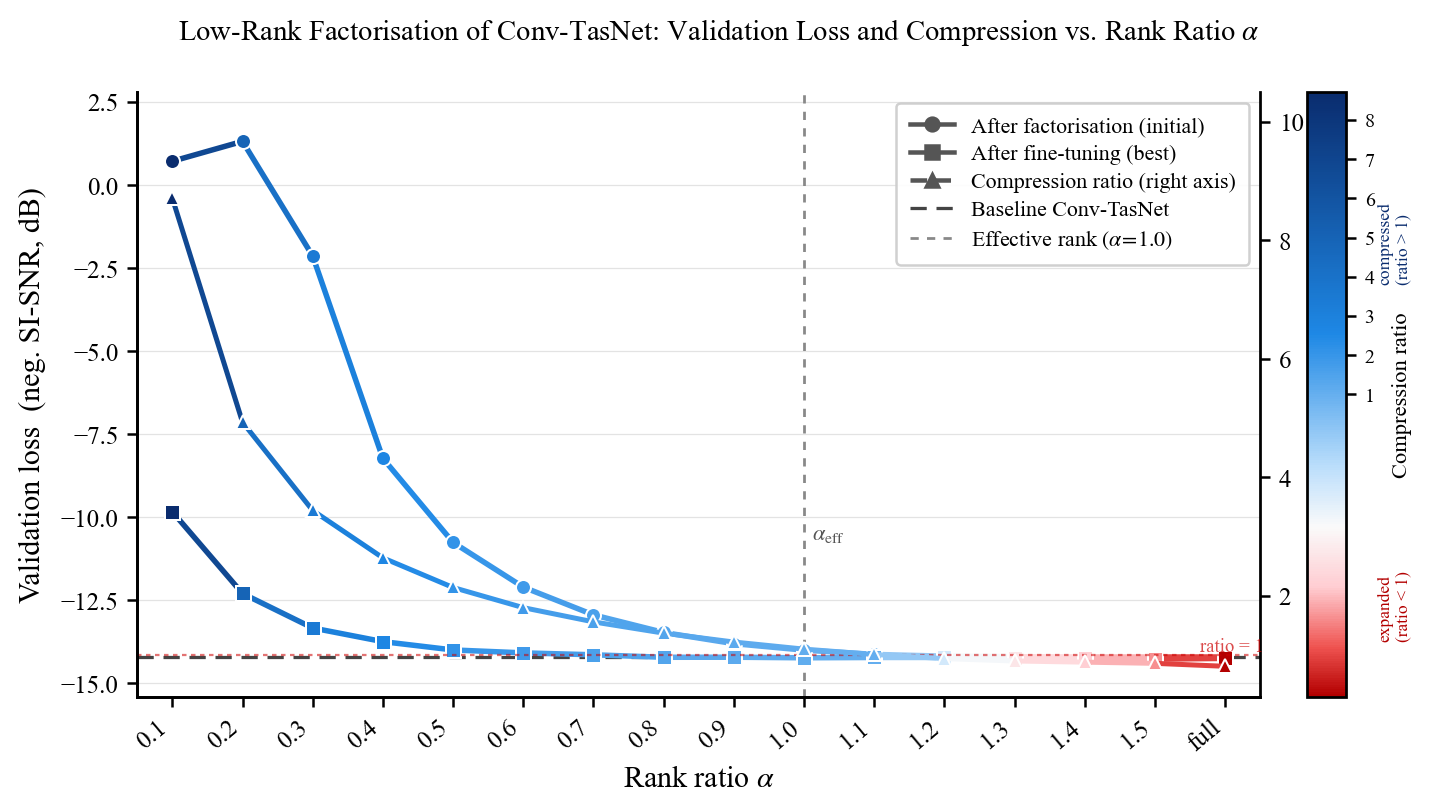

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.colorbar import ColorbarBase
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# Data
# ─────────────────────────────────────────────
alpha_labels = [
    "0.1", "0.2", "0.3", "0.4", "0.5",
    "0.6", "0.7", "0.8", "0.9", "1.0",
    "1.1", "1.2", "1.3", "1.4", "1.5", "full"
]
x = np.array(range(len(alpha_labels)), dtype=float)

best_loss = np.array([
    -9.8351, -12.2977, -13.3362, -13.7470, -13.9976,
    -14.0856, -14.1430, -14.2181, -14.2162, -14.2339,
    -14.2247, -14.2241, -14.2350, -14.2390, -14.2742, -14.2507
])
initial_loss = np.array([
     0.7177,  1.3163, -2.1353, -8.2283, -10.7592,
    -12.1045, -12.9411, -13.4710, -13.8072, -14.0033,
    -14.1314, -14.1845, -14.2017, -14.2096, -14.2101, -14.2097
])
compression = np.array([
    8.71, 4.93, 3.44, 2.64, 2.14,
    1.80, 1.56, 1.37, 1.22, 1.10,
    1.01, 0.94, 0.90, 0.88, 0.86, 0.81
])

baseline_loss      = -14.2096
effective_rank_idx = alpha_labels.index("1.0")

# ─────────────────────────────────────────────
# Global rcParams — publication / ISMIR style
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif", "Palatino"],
    "mathtext.fontset":   "stix",          # STIX matches Times perfectly
    "font.size":          11,
    "axes.labelsize":     12,
    "axes.titlesize":     13,
    "axes.titlepad":      10,
    "axes.labelpad":      6,
    "axes.linewidth":     1.1,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.major.width":  1.0,
    "ytick.major.width":  1.0,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    9.5,
    "legend.framealpha":  0.92,
    "legend.edgecolor":   "#cccccc",
    "legend.borderpad":   0.6,
    "lines.linewidth":    2.0,
    "lines.markersize":   6,
    "grid.linewidth":     0.5,
    "grid.alpha":         0.35,
    "figure.dpi":         180,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# ─────────────────────────────────────────────
# Colormap  — blue (compressed) / red (expanded)
# Pivot = compression ratio of 1.0
#   ratio > 1  →  blue  (deeper = heavier compression)
#   ratio < 1  →  red   (deeper = more expansion)
# ─────────────────────────────────────────────
# Custom diverging: deep-blue → white → deep-red  (reversed so blue=high)
blue_red_cmap = mcolors.LinearSegmentedColormap.from_list(
    "BlueRed",
    [
        (0.00, "#b30000"),   # deep red   (ratio << 1)
        (0.08, "#ef5350"),
        (0.18, "#ffcdd2"),
        (0.28, "#fafafa"),   # white at ratio = 1
        (0.38, "#bbdefb"),
        (0.60, "#1e88e5"),
        (1.00, "#0a2c6e"),   # deep blue  (ratio >> 1)
    ]
)

# We want the white centre to land exactly at ratio = 1.
# Use TwoSlopeNorm: below-1 mapped to [0, 0.28], above-1 to [0.28, 1]
norm = mcolors.TwoSlopeNorm(vmin=compression.min(),
                             vcenter=1.0,
                             vmax=compression.max())

def seg_color(ratio_val):
    """Return RGBA for a given compression ratio."""
    return blue_red_cmap(norm(ratio_val))

# ─────────────────────────────────────────────
# Build LineCollections (mid-point coloring per segment)
# ─────────────────────────────────────────────
def make_lc(x_arr, y_arr, ratios, lw=2.0):
    """
    Create a LineCollection where each segment i→i+1 is coloured by the
    average compression ratio of its two endpoints.
    """
    points  = np.array([x_arr, y_arr]).T.reshape(-1, 1, 2)
    segs    = np.concatenate([points[:-1], points[1:]], axis=1)
    mid_r   = 0.5 * (ratios[:-1] + ratios[1:])
    colors  = [seg_color(r) for r in mid_r]
    lc      = LineCollection(segs, colors=colors, linewidth=lw,
                             capstyle="round", joinstyle="round",
                             zorder=3)
    return lc, colors

lc_best,    col_best    = make_lc(x, best_loss,    compression, lw=2.2)
lc_initial, col_initial = make_lc(x, initial_loss, compression, lw=2.2)
lc_comp,    _           = make_lc(x, compression,  compression, lw=2.0)

# ─────────────────────────────────────────────
# Figure layout:  main axes  +  narrow colorbar axes
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(8.5, 4.6))
gs  = gridspec.GridSpec(
    1, 2,
    width_ratios=[1, 0.035],
    left=0.09, right=0.88,
    bottom=0.15, top=0.88,
    wspace=0.08
)
ax    = fig.add_subplot(gs[0])   # main plot
ax_cb = fig.add_subplot(gs[1])   # colorbar

# ─── Twin axis for compression ratio ─────────
ax2 = ax.twinx()
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_linewidth(1.1)
ax2.spines["top"].set_visible(False)

# ─────────────────────────────────────────────
# Draw on primary axis (loss)
# ─────────────────────────────────────────────
ax.add_collection(lc_initial)
ax.add_collection(lc_best)

# Scatter markers coloured individually
for i in range(len(x)):
    c = seg_color(compression[i])
    ax.plot(x[i], initial_loss[i], marker='o', color=c,
            markeredgecolor='white', markeredgewidth=0.8,
            markersize=6, zorder=4, linestyle='none')
    ax.plot(x[i], best_loss[i],    marker='s', color=c,
            markeredgecolor='white', markeredgewidth=0.8,
            markersize=6, zorder=4, linestyle='none')

# Baseline & effective rank reference lines
ax.axhline(baseline_loss, color='#444444', linestyle=(0, (5, 3)),
           linewidth=1.3, zorder=2, label=r'Baseline Conv-TasNet')
ax.axvline(effective_rank_idx, color='#888888', linestyle=(0, (3, 3)),
           linewidth=1.1, zorder=2, label=r'Effective rank $(\alpha\!=\!1.0)$')

# Annotate effective rank line
ax.text(effective_rank_idx + 0.12, -10.5,
        r'$\alpha_{\mathrm{eff}}$',
        fontsize=9, color='#555555', style='italic', va='center')

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_ylim(-15.4, 2.8)
ax.set_xticks(x)
ax.set_xticklabels(alpha_labels, rotation=40, ha='right')
ax.set_xlabel(r'Rank ratio $\alpha$', labelpad=4)
ax.set_ylabel(r'Validation loss  (neg. SI-SNR, dB)', labelpad=6)
ax.yaxis.grid(True, zorder=1)
ax.set_axisbelow(True)

# Proxy legend entries (no colour — colour is captured by colorbar)
from matplotlib.lines import Line2D
proxy_initial = Line2D([0], [0], marker='o', color='#555555',
                       markerfacecolor='#555555', markersize=5.5,
                       linewidth=1.8, label='After factorisation (initial)')
proxy_best    = Line2D([0], [0], marker='s', color='#555555',
                       markerfacecolor='#555555', markersize=5.5,
                       linewidth=1.8, label='After fine-tuning (best)')
proxy_cr      = Line2D([0], [0], marker='^', color='#555555',
                       markerfacecolor='#555555', markersize=5.5,
                       linewidth=1.8, linestyle='--',
                       label='Compression ratio (right axis)')
proxy_base    = Line2D([0], [0], linestyle=(0, (5, 3)), color='#444444',
                       linewidth=1.3, label=r'Baseline Conv-TasNet')
proxy_eff     = Line2D([0], [0], linestyle=(0, (3, 3)), color='#888888',
                       linewidth=1.1, label=r'Effective rank $(\alpha\!=\!1.0)$')

ax.legend(
    handles=[proxy_initial, proxy_best, proxy_cr, proxy_base, proxy_eff],
    loc='upper right', framealpha=0.92, fontsize=8.8,
    handlelength=2.0, labelspacing=0.35
)

# ─────────────────────────────────────────────
# Draw on secondary axis (compression ratio)
# ─────────────────────────────────────────────
ax2.add_collection(lc_comp)

for i in range(len(x)):
    c = seg_color(compression[i])
    ax2.plot(x[i], compression[i], marker='^', color=c,
             markeredgecolor='white', markeredgewidth=0.8,
             markersize=5.5, zorder=4, linestyle='none')

ax2.axhline(1.0, color='#cc0000', linestyle=(0, (2, 2)),
            linewidth=0.9, alpha=0.55, zorder=2)
ax2.set_xlim(-0.5, len(x) - 0.5)
ax2.set_ylim(0.3, 10.5)
# ax2.set_ylabel('Compression ratio', labelpad=6)
ax2.yaxis.label.set_color('#333333')

# Minor horizontal reference at ratio = 1
ax2.text(len(x) - 0.45, 1.06, 'ratio = 1',
         fontsize=7.5, color='#cc0000', alpha=0.7, ha='right')

# ─────────────────────────────────────────────
# Colorbar
# ─────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=blue_red_cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, cax=ax_cb)
cb.set_label('Compression ratio', fontsize=9, labelpad=7)
cb.ax.tick_params(labelsize=8)

# Mark ratio = 1 on the colorbar
cb.ax.axhline(norm(1.0), color='#333333', linewidth=1.2, linestyle='--')
cb.ax.text(2.6, norm(1.0), '1.0', va='center',
           fontsize=7.5, color='#333333', transform=cb.ax.transData)

# Shade: blue region label
cb.ax.text(1.8, 0.75, 'compressed\n(ratio > 1)',
           transform=cb.ax.transAxes, fontsize=7,
           color='#0a2c6e', ha='left', va='center', rotation=90)
cb.ax.text(1.8, 0.15, 'expanded\n(ratio < 1)',
           transform=cb.ax.transAxes, fontsize=7,
           color='#b30000', ha='left', va='center', rotation=90)

# ─────────────────────────────────────────────
# Title
# ─────────────────────────────────────────────
fig.suptitle(
    'Low-Rank Factorization of Conv-TasNet: Validation Loss and Compression vs. Rank Ratio $\\alpha$',
    fontsize=11.5, y=0.97, x=0.47, ha='center', fontstyle='normal'
)

plt.savefig("experiment1_combined.pdf", format="pdf")
plt.savefig("experiment1_combined.png", format="png")
plt.show()


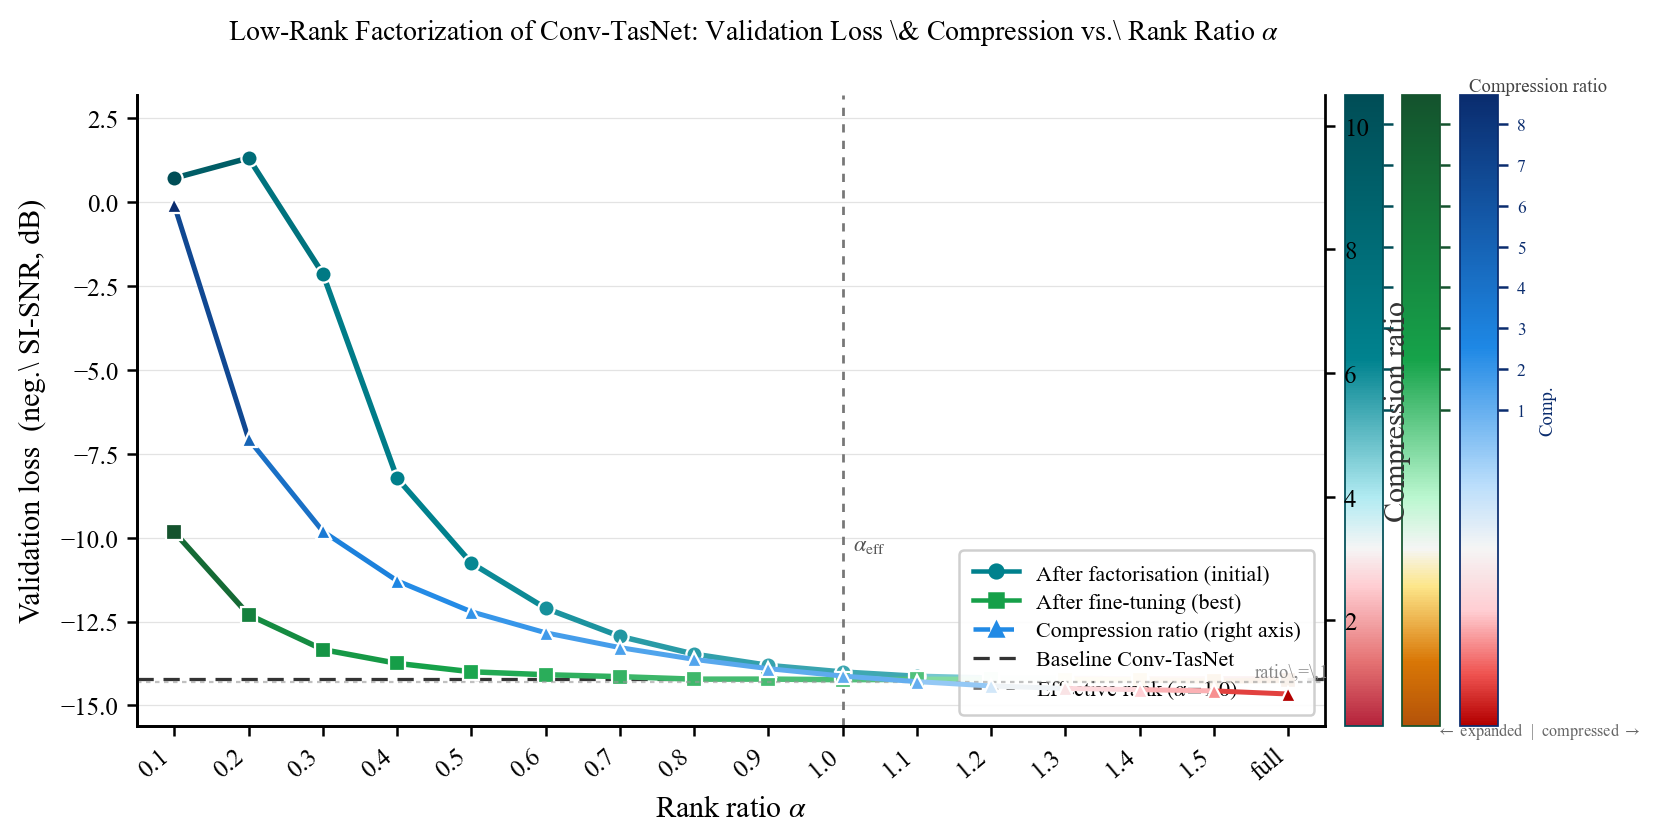

In [145]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────
# Data
# ─────────────────────────────────────────────
alpha_labels = [
    "0.1", "0.2", "0.3", "0.4", "0.5",
    "0.6", "0.7", "0.8", "0.9", "1.0",
    "1.1", "1.2", "1.3", "1.4", "1.5", "full"
]
x = np.array(range(len(alpha_labels)), dtype=float)

best_loss = np.array([
    -9.8351, -12.2977, -13.3362, -13.7470, -13.9976,
    -14.0856, -14.1430, -14.2181, -14.2162, -14.2339,
    -14.2247, -14.2241, -14.2350, -14.2390, -14.2742, -14.2507
])
initial_loss = np.array([
     0.7177,  1.3163, -2.1353, -8.2283, -10.7592,
    -12.1045, -12.9411, -13.4710, -13.8072, -14.0033,
    -14.1314, -14.1845, -14.2017, -14.2096, -14.2101, -14.2097
])
compression = np.array([
    8.71, 4.93, 3.44, 2.64, 2.14,
    1.80, 1.56, 1.37, 1.22, 1.10,
    1.01, 0.94, 0.90, 0.88, 0.86, 0.81
])

baseline_loss      = -14.2096
effective_rank_idx = alpha_labels.index("1.0")

# ─────────────────────────────────────────────
# rcParams — ISMIR publication style
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif", "Palatino"],
    "mathtext.fontset":   "stix",
    "font.size":          11,
    "axes.labelsize":     12,
    "axes.titlesize":     13,
    "axes.titlepad":      10,
    "axes.labelpad":      6,
    "axes.linewidth":     1.1,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.major.width":  1.0,
    "ytick.major.width":  1.0,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    9.0,
    "legend.framealpha":  0.93,
    "legend.edgecolor":   "#cccccc",
    "legend.borderpad":   0.6,
    "lines.linewidth":    2.0,
    "lines.markersize":   6,
    "grid.linewidth":     0.5,
    "grid.alpha":         0.35,
    "figure.dpi":         180,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# ─────────────────────────────────────────────
# Three per-line diverging colormaps
# All share the same norm (pivot at ratio = 1)
# Compressed  (ratio > 1) → cool/saturated hue
# Expanded    (ratio < 1) → warm/muted hue
# Near 1.0               → near-white neutral
# ─────────────────────────────────────────────

# Line 1 — Initial loss:  Cyan / Teal  ↔  Coral / Rose
cmap_initial = mcolors.LinearSegmentedColormap.from_list(
    "CyanCoral",
    [
        (0.00, "#b5243c"),   # deep coral-rose   (ratio << 1)
        (0.10, "#e57373"),
        (0.22, "#ffcdd2"),
        (0.28, "#f5f5f5"),   # neutral centre at ratio = 1
        (0.36, "#b2ebf2"),
        (0.58, "#00838f"),
        (1.00, "#004d56"),   # deep teal-cyan     (ratio >> 1)
    ]
)

# Line 2 — Best loss:  Forest Green / Olive  ↔  Amber / Gold
cmap_best = mcolors.LinearSegmentedColormap.from_list(
    "GreenAmber",
    [
        (0.00, "#b45309"),   # deep amber-brown   (ratio << 1)
        (0.10, "#d97706"),
        (0.22, "#fde68a"),
        (0.28, "#f5f5f5"),   # neutral centre at ratio = 1
        (0.36, "#bbf7d0"),
        (0.58, "#16a34a"),
        (1.00, "#14532d"),   # deep forest green  (ratio >> 1)
    ]
)

# Line 3 — Compression ratio:  Navy Blue  ↔  Crimson  (original feel)
cmap_comp = mcolors.LinearSegmentedColormap.from_list(
    "NavyCrimson",
    [
        (0.00, "#b30000"),   # deep crimson       (ratio << 1)
        (0.08, "#ef5350"),
        (0.18, "#ffcdd2"),
        (0.28, "#f5f5f5"),   # neutral centre at ratio = 1
        (0.38, "#bbdefb"),
        (0.60, "#1e88e5"),
        (1.00, "#0a2c6e"),   # deep navy          (ratio >> 1)
    ]
)

# Shared norm — TwoSlopeNorm pivoted at ratio = 1
norm = mcolors.TwoSlopeNorm(
    vmin=compression.min(),
    vcenter=1.0,
    vmax=compression.max()
)

def seg_color(cmap, ratio_val):
    """Return RGBA for a given compression ratio using specified cmap."""
    return cmap(norm(ratio_val))

# ─────────────────────────────────────────────
# LineCollection builder
# ─────────────────────────────────────────────
def make_lc(x_arr, y_arr, ratios, cmap, lw=2.0):
    points = np.array([x_arr, y_arr]).T.reshape(-1, 1, 2)
    segs   = np.concatenate([points[:-1], points[1:]], axis=1)
    mid_r  = 0.5 * (ratios[:-1] + ratios[1:])
    colors = [seg_color(cmap, r) for r in mid_r]
    lc     = LineCollection(segs, colors=colors, linewidth=lw,
                            capstyle="round", joinstyle="round", zorder=3)
    return lc

lc_initial = make_lc(x, initial_loss, compression, cmap_initial, lw=2.2)
lc_best    = make_lc(x, best_loss,    compression, cmap_best,    lw=2.2)
lc_comp    = make_lc(x, compression,  compression, cmap_comp,    lw=2.0)

# ─────────────────────────────────────────────
# Figure layout: main axes + colorbar column
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(9.0, 4.8))
gs  = gridspec.GridSpec(
    1, 4,
    width_ratios=[1, 0.032, 0.032, 0.032],
    left=0.09, right=0.93,
    bottom=0.15, top=0.88,
    wspace=0.06
)
ax     = fig.add_subplot(gs[0])
ax_cb1 = fig.add_subplot(gs[1])   # colorbar for initial loss
ax_cb2 = fig.add_subplot(gs[2])   # colorbar for best loss
ax_cb3 = fig.add_subplot(gs[3])   # colorbar for compression ratio

# Twin axis for compression ratio (right y-axis)
ax2 = ax.twinx()
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_linewidth(1.1)
ax2.spines["top"].set_visible(False)

# ─────────────────────────────────────────────
# Draw loss lines on primary axis
# ─────────────────────────────────────────────
ax.add_collection(lc_initial)
ax.add_collection(lc_best)

for i in range(len(x)):
    # Initial loss markers — circles, cyan/coral family
    c_init = seg_color(cmap_initial, compression[i])
    ax.plot(x[i], initial_loss[i],
            marker='o', color=c_init,
            markeredgecolor='white', markeredgewidth=0.9,
            markersize=6.5, zorder=5, linestyle='none')

    # Best loss markers — squares, green/amber family
    c_best = seg_color(cmap_best, compression[i])
    ax.plot(x[i], best_loss[i],
            marker='s', color=c_best,
            markeredgecolor='white', markeredgewidth=0.9,
            markersize=6.5, zorder=5, linestyle='none')

# Reference lines
ax.axhline(baseline_loss, color='#333333', linestyle=(0, (5, 3)),
           linewidth=1.3, zorder=2)
ax.axvline(effective_rank_idx, color='#777777', linestyle=(0, (3, 3)),
           linewidth=1.1, zorder=2)
ax.text(effective_rank_idx + 0.14, -10.2,
        r'$\alpha_{\mathrm{eff}}$',
        fontsize=9, color='#555555', style='italic', va='center')

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_ylim(-15.6, 3.2)
ax.set_xticks(x)
ax.set_xticklabels(alpha_labels, rotation=40, ha='right')
ax.set_xlabel(r'Rank ratio $\alpha$', labelpad=4)
ax.set_ylabel(r'Validation loss  (neg.\ SI-SNR, dB)', labelpad=6)
ax.yaxis.grid(True, zorder=1)
ax.set_axisbelow(True)

# ─────────────────────────────────────────────
# Draw compression ratio on secondary axis
# ─────────────────────────────────────────────
ax2.add_collection(lc_comp)

for i in range(len(x)):
    c_comp = seg_color(cmap_comp, compression[i])
    ax2.plot(x[i], compression[i],
             marker='^', color=c_comp,
             markeredgecolor='white', markeredgewidth=0.9,
             markersize=6.0, zorder=5, linestyle='none')

ax2.axhline(1.0, color='#999999', linestyle=(0, (2, 2)),
            linewidth=0.9, alpha=0.6, zorder=2)
ax2.set_xlim(-0.5, len(x) - 0.5)
ax2.set_ylim(0.3, 10.5)
ax2.set_ylabel('Compression ratio', labelpad=6, color='#333333')
ax2.text(len(x) - 0.45, 1.10, 'ratio\,=\,1',
         fontsize=7.5, color='#888888', ha='right')

# ─────────────────────────────────────────────
# Legend — colour swatches show representative
# mid-range colour for each line's cmap
# ─────────────────────────────────────────────
rep_init = seg_color(cmap_initial, 2.5)   # moderately compressed
rep_best = seg_color(cmap_best,    2.5)
rep_comp = seg_color(cmap_comp,    2.5)
rep_base = '#333333'
rep_eff  = '#777777'

proxy_initial = Line2D([0], [0], marker='o', color=rep_init,
                       markerfacecolor=rep_init, markersize=5.5,
                       linewidth=1.8, label='After factorisation (initial)')
proxy_best    = Line2D([0], [0], marker='s', color=rep_best,
                       markerfacecolor=rep_best, markersize=5.5,
                       linewidth=1.8, label='After fine-tuning (best)')
proxy_cr      = Line2D([0], [0], marker='^', color=rep_comp,
                       markerfacecolor=rep_comp, markersize=5.5,
                       linewidth=1.8, linestyle='--',
                       label='Compression ratio (right axis)')
proxy_base    = Line2D([0], [0], linestyle=(0, (5, 3)), color=rep_base,
                       linewidth=1.3, label=r'Baseline Conv-TasNet')
proxy_eff     = Line2D([0], [0], linestyle=(0, (3, 3)), color=rep_eff,
                       linewidth=1.1, label=r'Effective rank $(\alpha\!=\!1.0)$')

ax.legend(
    handles=[proxy_initial, proxy_best, proxy_cr, proxy_base, proxy_eff],
    loc='lower right', framealpha=0.93, fontsize=8.8,
    handlelength=2.1, labelspacing=0.38
)

# ─────────────────────────────────────────────
# Three slim colorbars — one per line
# ─────────────────────────────────────────────
def draw_colorbar(cax, cmap, label, label_color):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cax)
    cb.set_label(label, fontsize=7.5, labelpad=5, color=label_color)
    cb.ax.tick_params(labelsize=7, colors=label_color)
    cb.outline.set_edgecolor(label_color)
    cb.outline.set_linewidth(0.7)
    # Mark ratio = 1
    cb.ax.axhline(norm(1.0), color='#555555', linewidth=0.9, linestyle='--')
    return cb

# Representative colours for labels
cb1 = draw_colorbar(ax_cb1, cmap_initial, 'Init.',  '#004d56')
cb2 = draw_colorbar(ax_cb2, cmap_best,    'Best',   '#14532d')
cb3 = draw_colorbar(ax_cb3, cmap_comp,    'Comp.',  '#0a2c6e')

# Shared tick labels only on rightmost bar; suppress on the others
cb1.ax.set_yticklabels([])
cb2.ax.set_yticklabels([])

# ─────────────────────────────────────────────
# Colorbar group annotation
# ─────────────────────────────────────────────
fig.text(0.955, 0.88, 'Compression ratio',
         fontsize=7.5, color='#444444', ha='center', va='bottom', rotation=0)
fig.text(0.955, 0.155,
         r'$\leftarrow$ expanded  |  compressed $\rightarrow$',
         fontsize=6.5, color='#666666', ha='center', va='top', rotation=0)

# ─────────────────────────────────────────────
# Title
# ─────────────────────────────────────────────
fig.suptitle(
    r'Low-Rank Factorization of Conv-TasNet: '
    r'Validation Loss \& Compression vs.\ Rank Ratio $\alpha$',
    fontsize=11.2, y=0.97, x=0.47, ha='center'
)

plt.savefig("experiment1_combined.pdf", format="pdf")
plt.savefig("experiment1_combined.png", format="png")
plt.show()

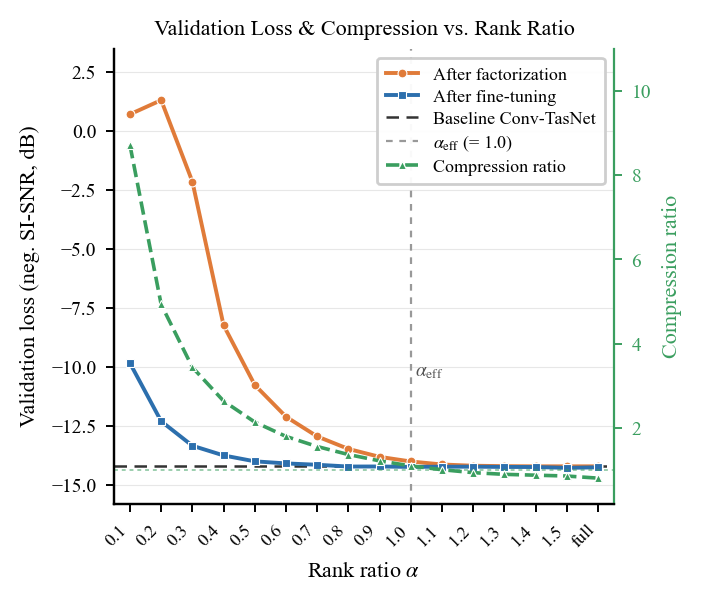

In [156]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────
# Data
# ─────────────────────────────────────────────
alpha_labels = [
    "0.1", "0.2", "0.3", "0.4", "0.5",
    "0.6", "0.7", "0.8", "0.9", "1.0",
    "1.1", "1.2", "1.3", "1.4", "1.5", "full"
]
x = np.array(range(len(alpha_labels)), dtype=float)

best_loss = np.array([
    -9.8351, -12.2977, -13.3362, -13.7470, -13.9976,
    -14.0856, -14.1430, -14.2181, -14.2162, -14.2339,
    -14.2247, -14.2241, -14.2350, -14.2390, -14.2742, -14.2507
])
initial_loss = np.array([
     0.7177,  1.3163, -2.1353, -8.2283, -10.7592,
    -12.1045, -12.9411, -13.4710, -13.8072, -14.0033,
    -14.1314, -14.1845, -14.2017, -14.2096, -14.2101, -14.2097
])
compression = np.array([
    8.71, 4.93, 3.44, 2.64, 2.14,
    1.80, 1.56, 1.37, 1.22, 1.10,
    1.01, 0.94, 0.90, 0.88, 0.86, 0.81
])

baseline_loss      = -14.2096
effective_rank_idx = alpha_labels.index("1.0")

# ─────────────────────────────────────────────
# rcParams — single-column conference style
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif", "Palatino"],
    "mathtext.fontset":  "stix",
    "font.size":         8,
    "axes.labelsize":    8,
    "axes.titlesize":    8,
    "axes.titlepad":     6,
    "axes.labelpad":     4,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   6.8,
    "legend.framealpha": 0.95,
    "legend.edgecolor":  "#cccccc",
    "legend.borderpad":  0.5,
    "legend.handlelength": 1.8,
    "legend.labelspacing": 0.3,
    "lines.linewidth":   1.4,
    "lines.markersize":  3.5,
    "grid.linewidth":    0.4,
    "grid.alpha":        0.3,
    "figure.dpi":        200,
    "savefig.dpi":       600,
    "savefig.bbox":      "tight",
})

# ─────────────────────────────────────────────
# Colours — three distinct, print-safe lines
# ─────────────────────────────────────────────
C_INITIAL  = "#e07b39"   # burnt orange  — initial loss
C_BEST     = "#2c6fad"   # steel blue    — best loss
C_COMP     = "#3a9e5f"   # forest green  — compression ratio
C_BASELINE = "#333333"   # near-black    — baseline reference
C_EFFRANK  = "#999999"   # grey          — effective rank reference

# ─────────────────────────────────────────────
# Figure — 3.4 in wide (one IEEE column)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.4, 2.9))

# ─── Twin axis for compression ratio ─────────
ax2 = ax.twinx()
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_linewidth(0.8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color(C_COMP)

# ─────────────────────────────────────────────
# Plot loss lines (primary axis)
# ─────────────────────────────────────────────
ax.plot(x, initial_loss,
        color=C_INITIAL, marker='o', markersize=3.2,
        linewidth=1.4, markeredgewidth=0.4, markeredgecolor='white',
        zorder=3, label='After factorization')

ax.plot(x, best_loss,
        color=C_BEST, marker='s', markersize=3.2,
        linewidth=1.4, markeredgewidth=0.4, markeredgecolor='white',
        zorder=3, label='After fine-tuning')

# Baseline reference
ax.axhline(baseline_loss,
           color=C_BASELINE, linestyle=(0, (5, 3)), linewidth=0.9,
           zorder=2, label='Baseline Conv-TasNet')

# Effective rank reference
ax.axvline(effective_rank_idx,
           color=C_EFFRANK, linestyle=(0, (3, 3)), linewidth=0.8,
           zorder=2, label=r'$\alpha_{\mathrm{eff}}$ (= 1.0)')
ax.text(effective_rank_idx + 0.14, -10.2,
        r'$\alpha_{\mathrm{eff}}$',
        fontsize=7, color='#555555', style='italic', va='center')

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_ylim(-15.8, 3.5)
ax.set_xticks(x)
ax.set_xticklabels(alpha_labels, rotation=45, ha='right', fontsize=6.5)
ax.set_xlabel(r'Rank ratio $\alpha$')
ax.set_ylabel(r'Validation loss (neg. SI-SNR, dB)')
ax.yaxis.grid(True, zorder=1)
ax.set_axisbelow(True)

# ─────────────────────────────────────────────
# Plot compression ratio (secondary axis)
# ─────────────────────────────────────────────
ax2.plot(x, compression,
         color=C_COMP, marker='^', markersize=3.0,
         linewidth=1.3, markeredgewidth=0.4, markeredgecolor='white',
         zorder=3, linestyle='--', label='Compression ratio')

ax2.axhline(1.0, color=C_COMP, linestyle=(0, (2, 2)),
            linewidth=0.7, alpha=0.5, zorder=2)

ax2.set_xlim(-0.5, len(x) - 0.5)
ax2.set_ylim(0.2, 11.0)
ax2.set_ylabel('Compression ratio', color=C_COMP)
ax2.tick_params(axis='y', colors=C_COMP, labelsize=7)

# ─────────────────────────────────────────────
# Unified legend (merge both axes)
# ─────────────────────────────────────────────
handles_ax1, labels_ax1 = ax.get_legend_handles_labels()
handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()

ax.legend(
    handles=handles_ax1 + handles_ax2,
    labels=labels_ax1  + labels_ax2,
    loc='upper right',
    framealpha=0.95,
    fontsize=6.5,
    ncol=1,
)

# ─────────────────────────────────────────────
# Title
# ─────────────────────────────────────────────
ax.set_title(
    r'Validation Loss & Compression vs. Rank Ratio',
    fontsize=8, pad=5
)

plt.tight_layout(pad=0.4)
plt.savefig("experiment1_column.pdf", format="pdf")
plt.savefig("experiment1_column.png", format="png")
plt.show()

## Train with Trancated Weights

### Problem — Two-factor AB is not the best factorization design

- The $W \approx AB$ decomposition has a well-known pathology called **implicit rank regularisation collapse**, identified in the implicit bias literature. During gradient descent, the two-factor product naturally biases toward low rank even when high rank is needed, because the gradient update to A depends on B and vice versa — they chase each other into a degenerate solution. This is not a feature here; it is a liability during the early high-rank exploration phase.

- When you initialise $A$ and $B$ randomly and train from scratch, you face the **symmetry-breaking problem**: because $W = AB$, permuting columns of A and rows of B leaves the product invariant. The gradient landscape has a continuous manifold of equivalent solutions. Early in training, the optimizer wanders along this manifold rather than descending toward a good solution, which severely slows convergence compared to training a full-rank W that has no such symmetry.The empirical evidence from the implicit bias literature (Arora et al., 2019; Li et al., 2021) is consistent: **training factored matrices from scratch reliably converges slower and to worse solutions than training full rank and then compressing**.

- If you optimize $W$ directly, gradient descent treats all directions in $W$-space more uniformly. If instead you write $W=UV$ and optimize $U,V$, the same $W$ can be represented in many ways, and the gradient dynamics are no longer those of plain optimization over $W$. That altered geometry tends to favor solutions where a few singular directions of $W$ grow and the rest stay small — i.e. effectively low-rank solutions (Gunasekar et al. (2017); Arora et al. (2019)).

Loading Round 1 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 data points (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 data points (epoch 1 → 100)

Loading Round 1 — checkpoints...
  Loaded best_val_loss from checkpoints: 100 data points (epoch 1 → 100)

Loading Round 2 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 50 data points (epoch 1 → 50)
  Loaded 'Epoch/Val_Loss': 50 data points (epoch 1 → 50)

Loading Round 2 — checkpoints...
  Loaded best_val_loss from checkpoints: 50 data points (epoch 1 → 50)

Round 1 global best → epoch 78  (loss -14.2096)
Round 2 epoch offset = 78  (R2 local ep 1 → global ep 79)

R2 Train Loss anchor injected at local ep 0 (global ep 78): -15.9203
R2 Val Loss + Best Val Loss anchor injected at local ep 0 (global ep 7

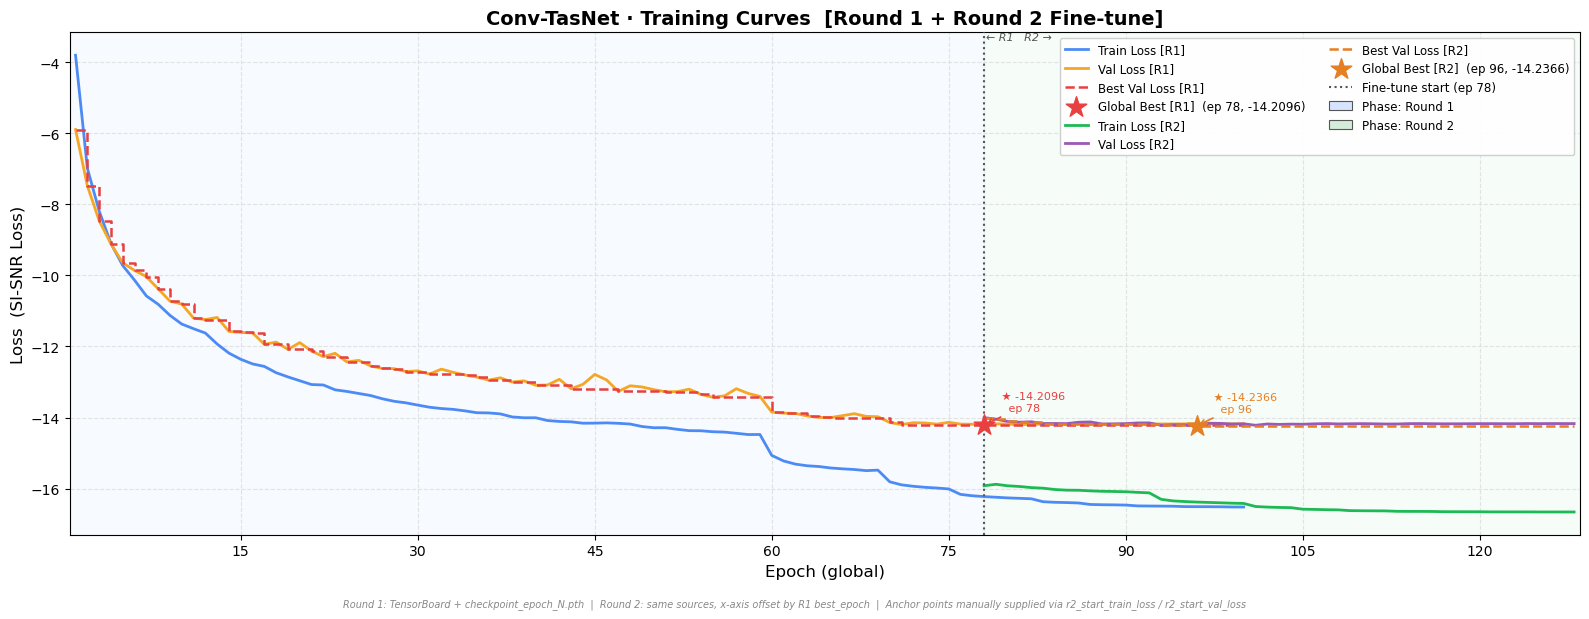

In [ ]:
fig = plot_training_curves_dual_round(
    # ── Round 1 paths ──────────────────────────────────
    r1_log_dir        = 'HPC_Trained/Task1/logs',
    r1_checkpoint_dir = 'HPC_Trained/Task1/checkpoints',

    # ── Round 2 paths ──────────────────────────────────
    r2_log_dir        = 'HPC_Trained/Task1_tune_free/logs',
    r2_checkpoint_dir = "HPC_Trained/Task1_tune_free/checkpoints",

    r2_start_train_loss = -15.920345165394878,   
    r2_start_val_loss   = -14.003267823525196,   

    # ── Options ────────────────────────────────────────
    # save_path         = "training_dual_round.png",
    figsize           = (16, 6),
    dpi               = 150,
    smooth_window     = 1,     # set to 1 to disable smoothing
)

plt.show()

Loading Round 1 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 data points (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 data points (epoch 1 → 100)

Loading Round 1 — checkpoints...
  Loaded best_val_loss from checkpoints: 100 data points (epoch 1 → 100)

Loading Round 2 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 50 data points (epoch 1 → 50)
  Loaded 'Epoch/Val_Loss': 50 data points (epoch 1 → 50)

Loading Round 2 — checkpoints...
  Loaded best_val_loss from checkpoints: 50 data points (epoch 1 → 50)

Round 1 global best → epoch 78  (loss -14.2096)
Round 2 epoch offset = 78  (R2 local ep 1 → global ep 79)

R2 Train Loss anchor injected at local ep 0 (global ep 78): -15.9203
R2 Val Loss + Best Val Loss anchor injected at local ep 0 (global ep 7

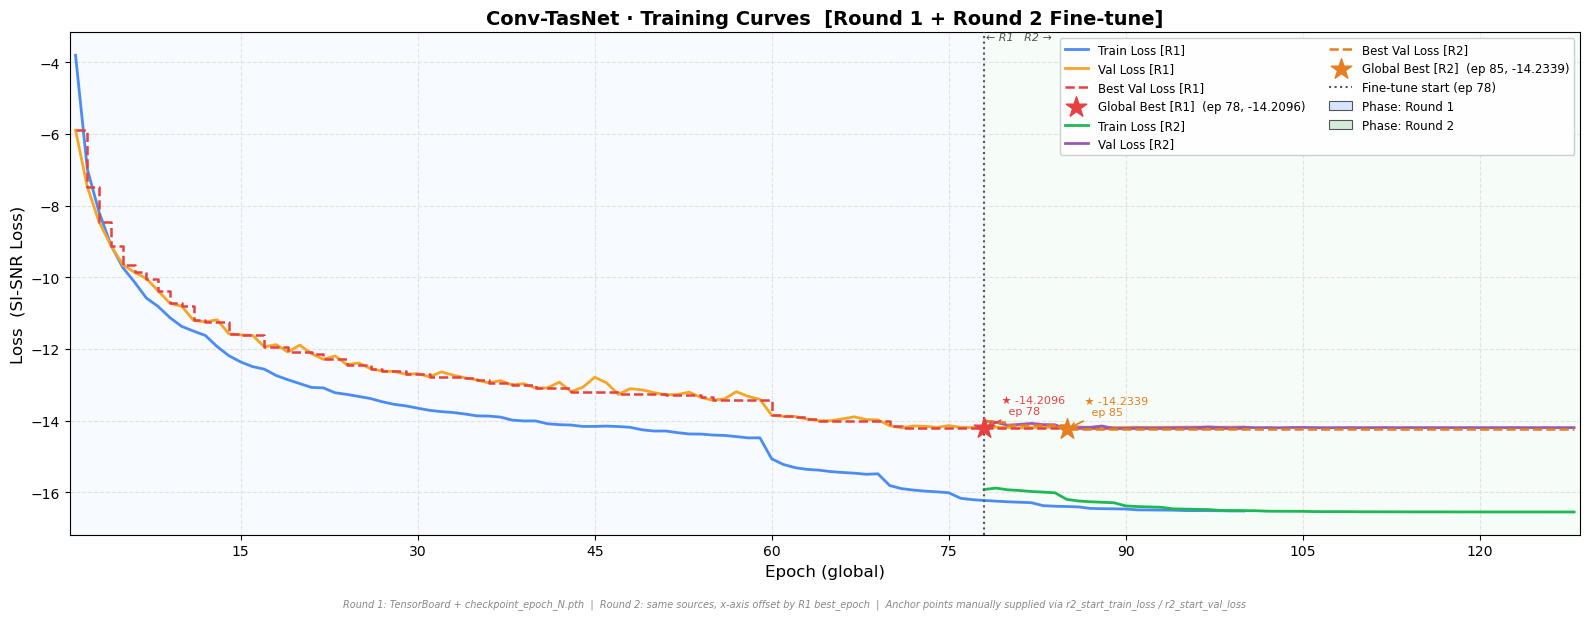

In [7]:
fig = plot_training_curves_dual_round(
    # ── Round 1 paths ──────────────────────────────────
    r1_log_dir        = 'HPC_Trained/Task1/logs',
    r1_checkpoint_dir = 'HPC_Trained/Task1/checkpoints',

    # ── Round 2 paths ──────────────────────────────────
    r2_log_dir        = 'HPC_Trained/Task1_tune_rebalance/logs',
    r2_checkpoint_dir = "HPC_Trained/Task1_tune_rebalance/checkpoints",

    r2_start_train_loss = -15.920345165394878,   
    r2_start_val_loss   = -14.003267823525196,   

    # ── Options ────────────────────────────────────────
    # save_path         = "training_dual_round.png",
    figsize           = (16, 6),
    dpi               = 150,
    smooth_window     = 1,     # set to 1 to disable smoothing
)

plt.show()

In [3]:
# %load_ext tensorboard
# %tensorboard --logdir HPC_Trained/Task1_tune_free/logs --port 7007

Loading Round 1 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 data points (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 data points (epoch 1 → 100)

Loading Round 1 — checkpoints...
  Loaded best_val_loss from checkpoints: 100 data points (epoch 1 → 100)

Loading Round 2 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 50 data points (epoch 1 → 50)
  Loaded 'Epoch/Val_Loss': 50 data points (epoch 1 → 50)

Loading Round 2 — checkpoints...
  Loaded best_val_loss from checkpoints: 50 data points (epoch 1 → 50)

Round 1 global best → epoch 66  (loss -14.0587)
Round 2 epoch offset = 66  (R2 local ep 1 → global ep 67)

R2 Train Loss anchor injected at local ep 0 (global ep 66): -15.9203
R2 Val Loss + Best Val Loss anchor injected at local ep 0 (global ep 6

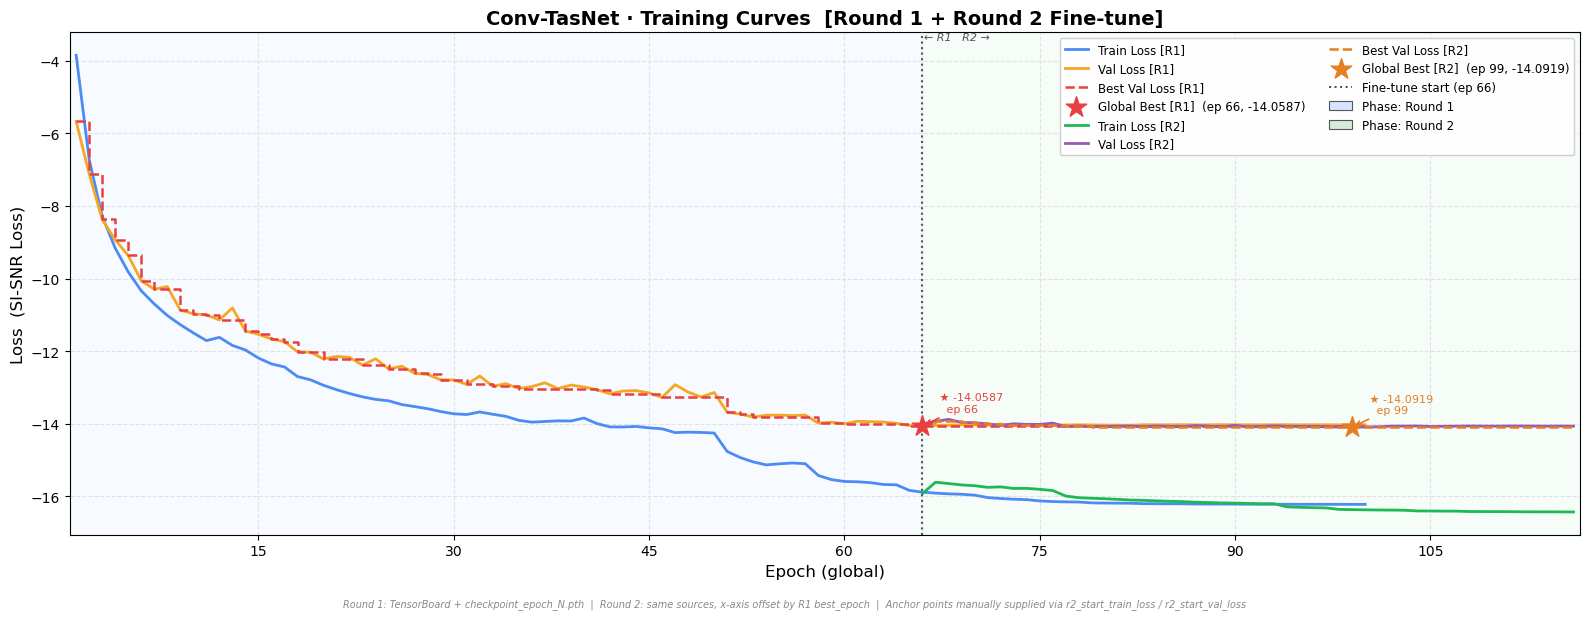

In [4]:
fig = plot_training_curves_dual_round(
    # ── Round 1 paths ──────────────────────────────────
    r1_log_dir        = 'HPC_Trained/Task2_kernel_30/logs',
    r1_checkpoint_dir = 'HPC_Trained/Task2_kernel_30/checkpoints',

    # ── Round 2 paths ──────────────────────────────────
    r2_log_dir        = 'HPC_Trained/Task2_kernel_30/Task2_kernel_30_tune_free/logs',
    r2_checkpoint_dir = "HPC_Trained/Task2_kernel_30/Task2_kernel_30_tune_free/checkpoints",

    r2_start_train_loss = -15.920345165394878,   
    r2_start_val_loss   = -14.003267823525196,   

    # ── Options ────────────────────────────────────────
    # save_path         = "training_dual_round.png",
    figsize           = (16, 6),
    dpi               = 150,
    smooth_window     = 1,     # set to 1 to disable smoothing
)

plt.show()

Loading Round 1 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 data points (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 data points (epoch 1 → 100)

Loading Round 1 — checkpoints...
  Loaded best_val_loss from checkpoints: 100 data points (epoch 1 → 100)

Loading Round 2 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 50 data points (epoch 1 → 50)
  Loaded 'Epoch/Val_Loss': 50 data points (epoch 1 → 50)

Loading Round 2 — checkpoints...
  Loaded best_val_loss from checkpoints: 50 data points (epoch 1 → 50)

Round 1 global best → epoch 66  (loss -14.0587)
Round 2 epoch offset = 66  (R2 local ep 1 → global ep 67)

R2 Train Loss anchor injected at local ep 0 (global ep 66): -15.9203
R2 Val Loss + Best Val Loss anchor injected at local ep 0 (global ep 6

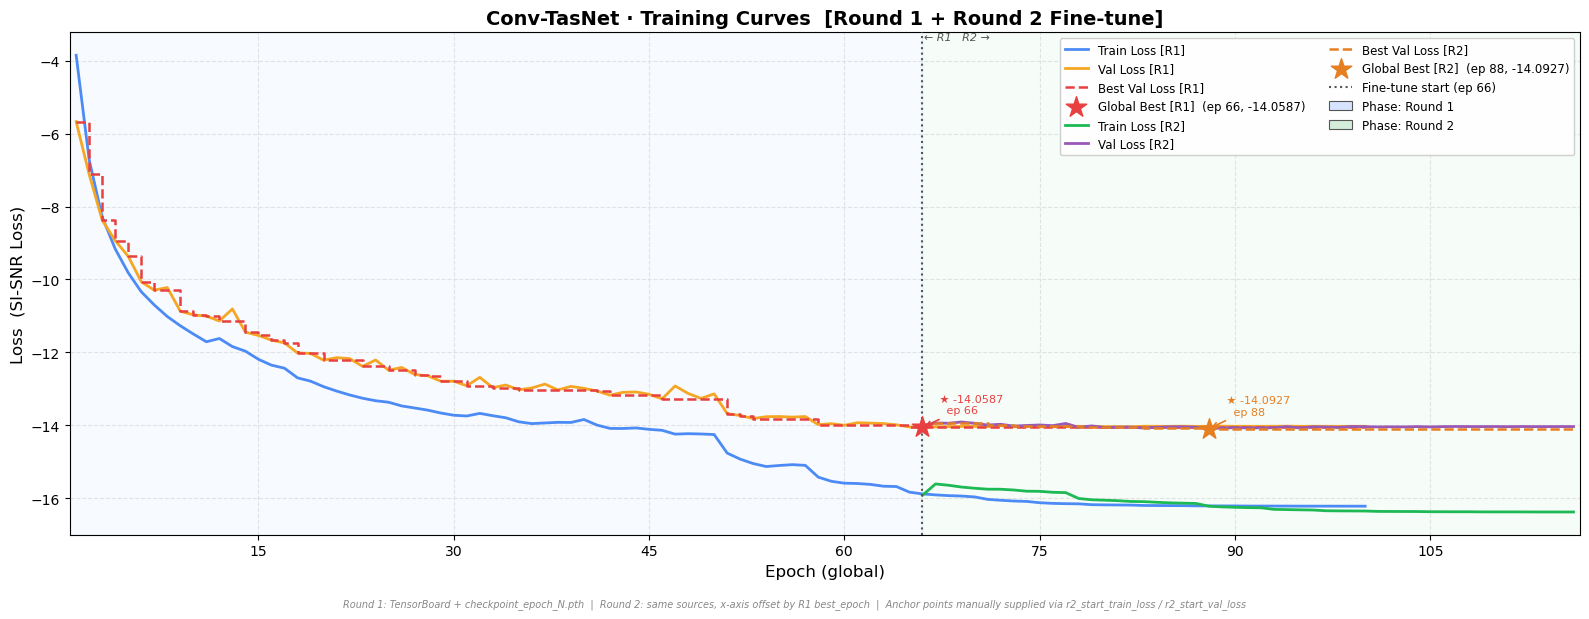

In [5]:
fig = plot_training_curves_dual_round(
    # ── Round 1 paths ──────────────────────────────────
    r1_log_dir        = 'HPC_Trained/Task2_kernel_30/logs',
    r1_checkpoint_dir = 'HPC_Trained/Task2_kernel_30/checkpoints',

    # ── Round 2 paths ──────────────────────────────────
    r2_log_dir        = 'HPC_Trained/Task2_kernel_30/Task2_kernel_30_tune_balance/logs',
    r2_checkpoint_dir = "HPC_Trained/Task2_kernel_30/Task2_kernel_30_tune_balance/checkpoints",

    r2_start_train_loss = -15.920345165394878,   
    r2_start_val_loss   = -14.003267823525196,   

    # ── Options ────────────────────────────────────────
    # save_path         = "training_dual_round.png",
    figsize           = (16, 6),
    dpi               = 150,
    smooth_window     = 1,     # set to 1 to disable smoothing
)

plt.show()

Loading Round 1 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 165 data points (epoch 1 → 165)
  Loaded 'Epoch/Val_Loss': 165 data points (epoch 1 → 165)

Loading Round 1 — checkpoints...
  Loaded best_val_loss from checkpoints: 165 data points (epoch 1 → 165)

Loading Round 2 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 50 data points (epoch 1 → 50)
  Loaded 'Epoch/Val_Loss': 50 data points (epoch 1 → 50)

Loading Round 2 — checkpoints...
  Loaded best_val_loss from checkpoints: 50 data points (epoch 1 → 50)

Round 1 global best → epoch 112  (loss -7.8056)
Round 2 epoch offset = 112  (R2 local ep 1 → global ep 113)

R2 Train Loss anchor injected at local ep 0 (global ep 112): -10.0000
R2 Val Loss + Best Val Loss anchor injected at local ep 0 (global e

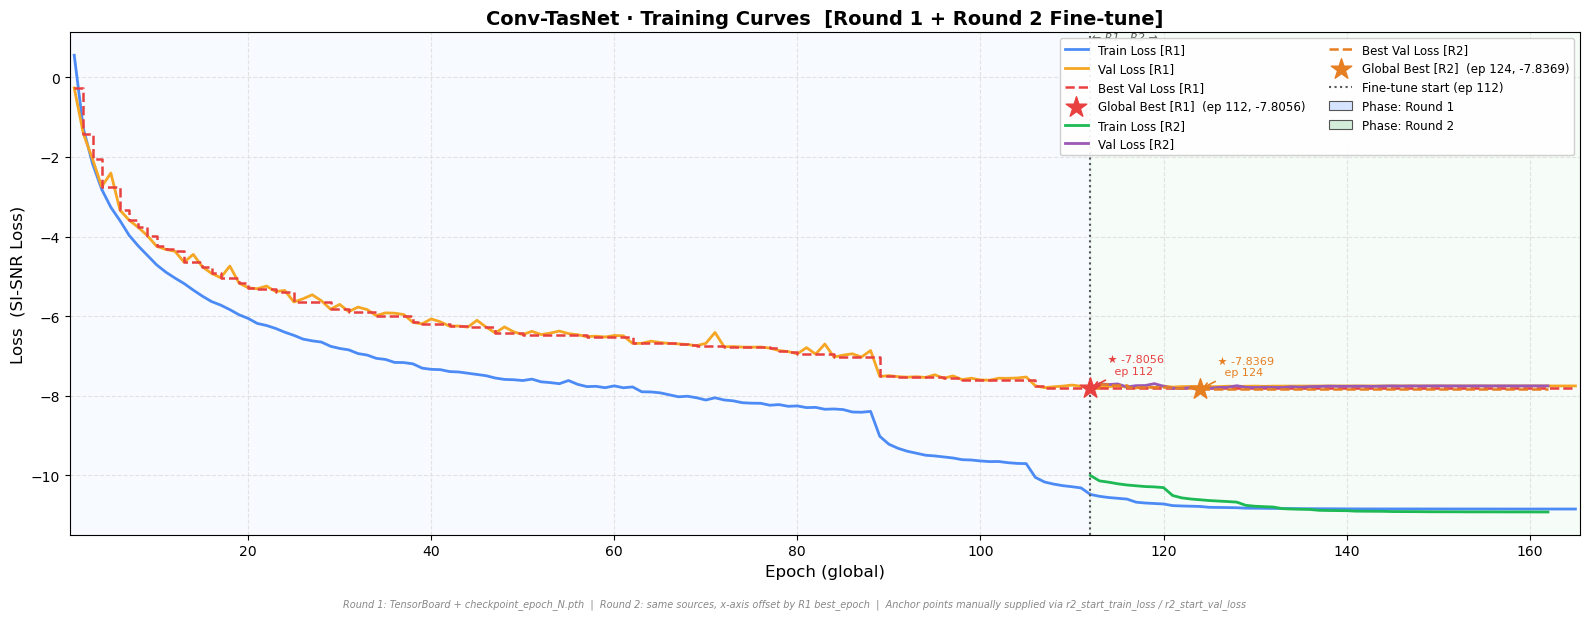

In [8]:
fig = plot_training_curves_dual_round(
    # ── Round 1 paths ──────────────────────────────────
    r1_log_dir        = 'HPC_Trained/Task3_3mix/logs',
    r1_checkpoint_dir = 'HPC_Trained/Task3_3mix/checkpoints',

    # ── Round 2 paths ──────────────────────────────────
    r2_log_dir        = 'HPC_Trained/Task3_3mix/Task3_3mix_tune_free/logs',
    r2_checkpoint_dir = "HPC_Trained/Task3_3mix/Task3_3mix_tune_free/checkpoints",

    r2_start_train_loss = -10,   
    r2_start_val_loss   = -7.8,   

    # ── Options ────────────────────────────────────────
    # save_path         = "training_dual_round.png",
    figsize           = (16, 6),
    dpi               = 150,
    smooth_window     = 1,     # set to 1 to disable smoothing
)

plt.show()

Loading Round 1 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 165 data points (epoch 1 → 165)
  Loaded 'Epoch/Val_Loss': 165 data points (epoch 1 → 165)

Loading Round 1 — checkpoints...
  Loaded best_val_loss from checkpoints: 165 data points (epoch 1 → 165)

Loading Round 2 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 50 data points (epoch 1 → 50)
  Loaded 'Epoch/Val_Loss': 50 data points (epoch 1 → 50)

Loading Round 2 — checkpoints...
  Loaded best_val_loss from checkpoints: 50 data points (epoch 1 → 50)

Round 1 global best → epoch 112  (loss -7.8056)
Round 2 epoch offset = 112  (R2 local ep 1 → global ep 113)

R2 Train Loss anchor injected at local ep 0 (global ep 112): -10.0000
R2 Val Loss + Best Val Loss anchor injected at local ep 0 (global e

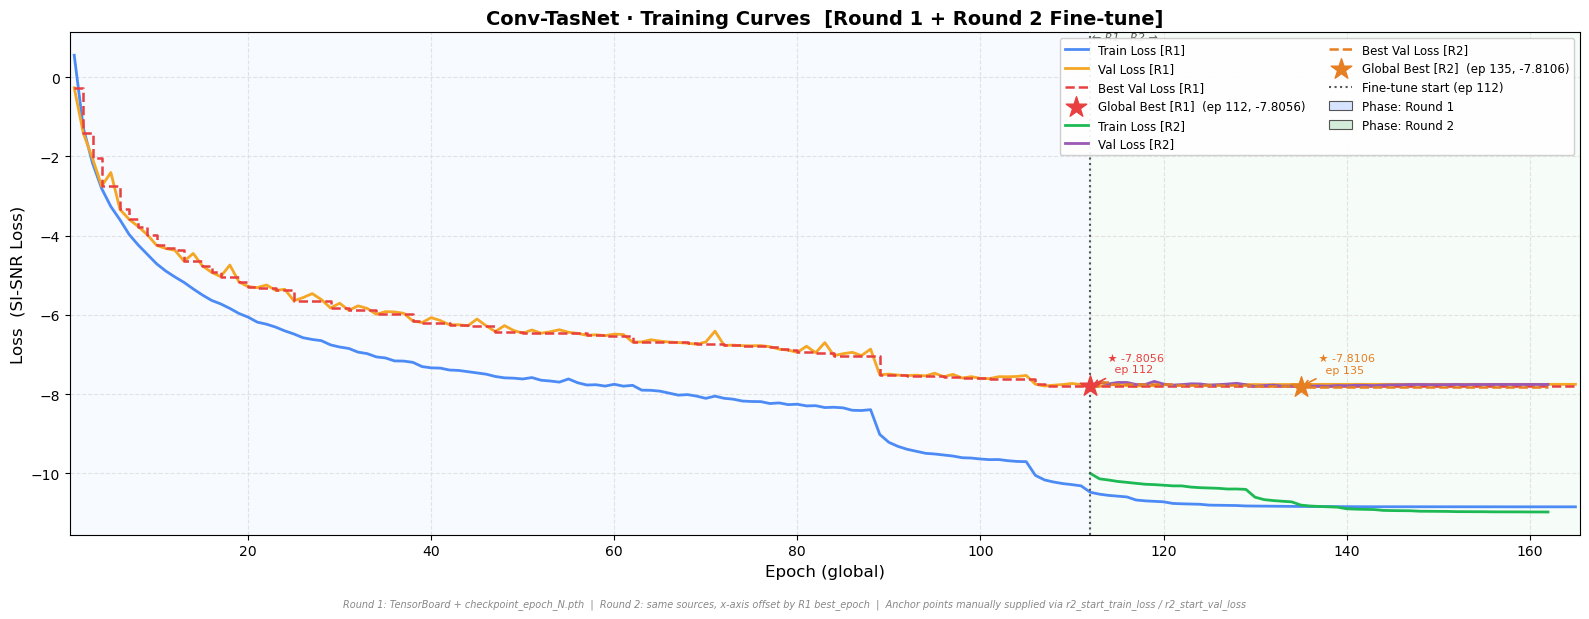

In [9]:
fig = plot_training_curves_dual_round(
    # ── Round 1 paths ──────────────────────────────────
    r1_log_dir        = 'HPC_Trained/Task3_3mix/logs',
    r1_checkpoint_dir = 'HPC_Trained/Task3_3mix/checkpoints',

    # ── Round 2 paths ──────────────────────────────────
    r2_log_dir        = 'HPC_Trained/Task3_3mix/Task3_3mix_tune_balance/logs',
    r2_checkpoint_dir = "HPC_Trained/Task3_3mix/Task3_3mix_tune_balance/checkpoints",

    r2_start_train_loss = -10,   
    r2_start_val_loss   = -7.8,   

    # ── Options ────────────────────────────────────────
    # save_path         = "training_dual_round.png",
    figsize           = (16, 6),
    dpi               = 150,
    smooth_window     = 1,     # set to 1 to disable smoothing
)

plt.show()